In [1]:
import matplotlib as mpl
from numpy import dtype


mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import polars as pl
import itertools
import warnings
from scipy.sparse import csr_matrix
from scipy import stats
import scipy.ndimage as ndimage
from textwrap import wrap
import statsmodels.api as sm
from matplotlib.colors import LogNorm
import cvxpy as cp


sns.set(style="ticks", palette="Set2", context="notebook", rc={'axes.formatter.limits': (-3, 3)}, )
warnings.filterwarnings(action='ignore')

RELOAD_ACCESSION_DATA = False

In [2]:
def read_names(file_path):
    return np.genfromtxt(file_path, dtype=str, delimiter="\n")

complex_ids = read_names("data/complex_ids.txt")
monomer_ids = read_names("data/protein_ids.txt")
cofactor_ids = read_names("data/cofactor_ids.txt")
element_ids = read_names("data/element_ids.txt")
protein_ids = complex_ids.tolist() + monomer_ids.tolist()

# Reading the matrix CSV files
def read_matrix(file_path, sparse=False):
    # add sparse matrix reading
    if sparse:
        return csr_matrix(pl.read_csv(file_path, has_header=False).to_numpy())
    else:
        return pl.read_csv(file_path, has_header=False).to_numpy()

C = read_matrix("data/C_matrix.csv", sparse=True)
P = read_matrix("data/P_matrix.csv", sparse=True)
E = read_matrix("data/E_matrix.csv", sparse=True)
Tree = read_matrix("data/tree_matrix.csv", sparse=True)
tree_ids = complex_ids.tolist() + monomer_ids.tolist() + cofactor_ids.tolist()

total_counts_min = read_matrix("data/counts.csv")

element_isotope_mapping = {"MG": "25Mg", "MG2": "26Mg", "GA": "71Ga", "GE":"73Ge", "SI": "29Si", "P": "31P", "S": "34S", "CA":"44Ca",
                           "MN": "55Mn", "CU": "63Cu", "MO": "95Mo", "NI": "60Ni", "FE":"56Fe", 
                           "ZN": "66Zn", "W": "182W", "CO": "59Co",
                           "CD": "111Cd", "PB": "208Pb", "CR": "52Cr", "V": "51V", "SE": "77Se", "HG": "202Hg", "AS": "75As", "SB": "121Sb", "TL": "205Tl",
                           "AL": "27Al", "TI": "47Ti", "TI2": "48Ti", "FE2": "57Fe", "IN": "115In", "SN": "118Sn","BI": "209Bi",}
# reverse mapping
isotope_element_mapping = {v: k for k, v in element_isotope_mapping.items()}

## import conversion table

In [3]:
conversion_df = pl.read_csv("external_data/metalloproteome_exp_conversion.csv")

# get all unique values of End and Index
end_values = conversion_df["End"].unique().to_list()
index_values = conversion_df["Index"].unique().to_list()

# give each unique value a unique number
end_dict = {end: i for i, end in enumerate(end_values)}
index_dict = {index: i for i, index in enumerate(index_values)}

# create a new column for the unique value
conversion_df = conversion_df.with_columns(x=pl.col("End").replace(end_dict))
conversion_df = conversion_df.with_columns(y=pl.col("Index").replace(index_dict))

# drop start end index
conversion_df = conversion_df.drop(["Start", "End", "Index"])

conversion_df

Experiment,x,y
str,i64,i64
"""0to0_1""",0,0
"""0to0_2""",0,1
"""0to0_3""",0,2
"""0to0_4""",0,3
"""0to0_5""",0,4
…,…,…
"""900to1000_28""",17,27
"""900to1000_29""",17,28
"""900to1000_30""",17,29


In [4]:
conversion_df.unique("y")

Experiment,x,y
str,i64,i64
"""0to0_27""",0,26
"""0to0_12""",0,11
"""0to0_17""",0,16
"""0to0_28""",0,27
"""0to0_16""",0,15
…,…,…
"""0to0_23""",0,22
"""0to0_5""",0,4
"""0to0_29""",0,28


In [5]:
# load gene df
gene_df = pl.read_csv("data/accession_gene_dict.csv")

# convert to dict
gene_dict = dict(zip(gene_df["Accession Number"], gene_df["Gene Name"]))

gene_df

Accession Number,Gene Name
str,str
"""AAC76954.1""","""tufB"""
"""AAC76345.1""","""rplC"""
"""AAC76328.1""","""rpsE"""
"""AAC74990.1""","""fliC"""
"""AAC77103.1""","""groL"""
…,…
"""AAC75718.1""","""ygaC"""
"""AAC73987.1""","""ycaK"""
"""AAC77128.1""","""miaA"""


## Change column to gene name

In [6]:
# Load the data
prot_df_raw = pl.read_csv('external_data/metalloproteome_proteins.csv')

# drop "#", "Visible?", "Starred?", "Molecular Weight"
prot_df = prot_df_raw.drop(["#", "Visible?", "Starred?", "Molecular Weight", "Taxonomy"])

prot_df.head(5)

# change column to gene name
prot_df = prot_df.with_columns(Gene=pl.col("Accession Number").replace(gene_dict))

# drop Identified Proteins (1235), Accession Number
prot_df = prot_df.drop(["Identified Proteins (1235)", "Accession Number"])

# drop duplicate rows with the same gene name
prot_df = prot_df.unique(subset=["Gene"], maintain_order=True)

# transpose and keep gene as column names
prot_exp_names = list(prot_df.columns)[:-1]
gene_names = prot_df["Gene"].to_list()

In [7]:
# transpose and keep gene as column names
prot_df = prot_df.drop(["Gene"]).transpose()
prot_df.columns = gene_names

# add a new column, "Experiment"
prot_df = prot_df.with_columns(pl.Series(name="Experiment", values=prot_exp_names))

# join with the conversion table
prot_df = prot_df.join(conversion_df, on="Experiment")

prot_df

tufB,rplC,rpsE,fliC,groL,rpsT,rplD,rplX,rplR,rpsL,rplO,rplM,rpsA,rplV,icd,ilvC,rpsG,rpsN,rplN,rplB,rpsU,rplA,rplU,rpmB,carB,metE,eno,fusA,rpoB,rpoC,rpsI,hupA,rpsS,gapA,dppA,rpmD,oppA,…,tdh,hemN,chaB,yjhU,putA,hemF,efeB,paaY,yciG,yidC,dnaQ,fliK,yrdB,ybhB,yfaY,dnaJ,ybeL,fliD,ubiJ,ydeI,eutL,rarA,uxaC,tcdA,nikA,tolQ,ydcI,yedD,murB,ygaC,ycaK,miaA,fruK,ubiF,Experiment,x,y
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,i64
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""0to0_1""",0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""0to0_2""",0,1
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""0to0_3""",0,2
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""0to0_4""",0,3
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""0to0_5""",0,4
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""900to1000_28""",17,27
0,0,6,0,0,0,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""900to1000_29""",17,28
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""900to1000_30""",17,29


## Load the metal data

In [8]:
# load metal data
metal_df = pl.read_csv('external_data/metalloproteome_metals.csv')

# drop columns that started with "_dupli"
metal_df = metal_df.drop([col for col in metal_df.columns if col.startswith("_dupli")])

# drop columns without names
metal_df = metal_df.drop([col for col in metal_df.columns if len(col) < 2])

# for all float cols, subtract minimum value
# for col in metal_df.columns:
#     if metal_df[col].dtype == pl.Float64:
#         metal_df = metal_df.with_columns(pl.Series(name=col, values=metal_df[col] - 0.999 * metal_df[col].min()))

# extract list of metals
metals = metal_df.columns[1:]

metal_df

Experiment,25Mg,26Mg,29Si,31P,34S,44Ca,71Ga,73Ge,27Al,47Ti,48Ti,51V,52Cr,55Mn,56Fe,57Fe,59Co,60Ni,63Cu,66Zn,75As,77Se,95Mo,111Cd,115In,118Sn,121Sb,182W,202Hg,208Pb,209Bi
str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""0to0_1""",8823,11681,189919,328,3591,22496,38,6,86.974396,4.004968,5.167747,0.179796,0.876813,10.836837,10.552461,10.337697,0.057026,1.173599,0.500182,0.602304,0.0222,0.119779,0.117428,0.00104,-13.836556,0.09528,0.007665,40.403296,3.449361,0.016148,9.993649
"""0to0_2""",868,1179,180574,300,3436,7186,4,1,1.353013,0.095871,0.377731,0.108823,0.728478,6.006004,2.958434,2.69667,0.048106,1.077893,0.339914,0.524031,0.013567,0.299447,0.117188,0.000208,-13.536126,0.056937,0.007508,35.564532,2.891377,0.010286,10.862665
"""0to0_3""",831,1205,182317,291,3581,7155,1,0,1.516522,0.100229,0.403266,0.116908,0.722591,5.784571,3.121333,2.888219,0.056345,1.111941,0.300745,0.542167,0.013567,0.059889,0.114162,0.00104,-13.595515,0.044946,0.007039,37.500017,2.536294,0.00858,9.993649
"""0to0_4""",872,1080,184990,256,3621,7330,2,0,1.600319,0.082798,0.414614,0.112477,0.746018,5.556133,3.373253,3.177696,0.080347,1.251426,0.30058,0.603577,0.0259,0.029945,0.126954,0.001873,-13.555307,0.037981,0.006804,39.193624,2.58702,0.007826,8.907374
"""0to0_5""",1006,1303,183349,294,3635,7837,3,0,1.671855,0.069725,0.442581,0.117996,0.789342,5.53877,3.598385,3.239036,0.10545,1.430548,0.480732,0.702853,0.024667,0.239558,0.11815,0.002289,-13.657827,0.037335,0.009229,43.548493,3.347909,0.011981,8.255623
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""900to1000_28""",402,597,70454,322,3812,2631,0,0,1.099329,0.082724,0.189697,0.114594,0.271328,0.044113,1.119198,0.83295,0.006293,0.169676,0.18,0.172763,0.014881,0.159694,0.073712,0.0,-15.342357,0.021587,0.00541,18.588133,1.491532,0.003633,3.698081
"""900to1000_29""",431,557,71339,321,3947,2585,3,0,1.144876,0.078128,0.171669,0.112909,0.262306,0.041008,1.146955,0.85173,0.006668,0.180365,0.176192,0.168419,0.017362,0.031939,0.076596,0.000631,-15.345479,0.023709,0.004199,22.796756,1.789838,0.003382,4.88147
"""900to1000_30""",743,946,67673,268,3814,2738,1,0,1.115892,0.045958,0.195433,0.108098,0.225865,0.070682,1.009749,0.69928,0.00599,0.202633,0.174884,0.269673,0.019842,0.127755,0.074627,0.000421,-15.180415,0.022758,0.004441,16.133086,2.336734,0.004481,4.141853


<Axes: ylabel='66Zn'>

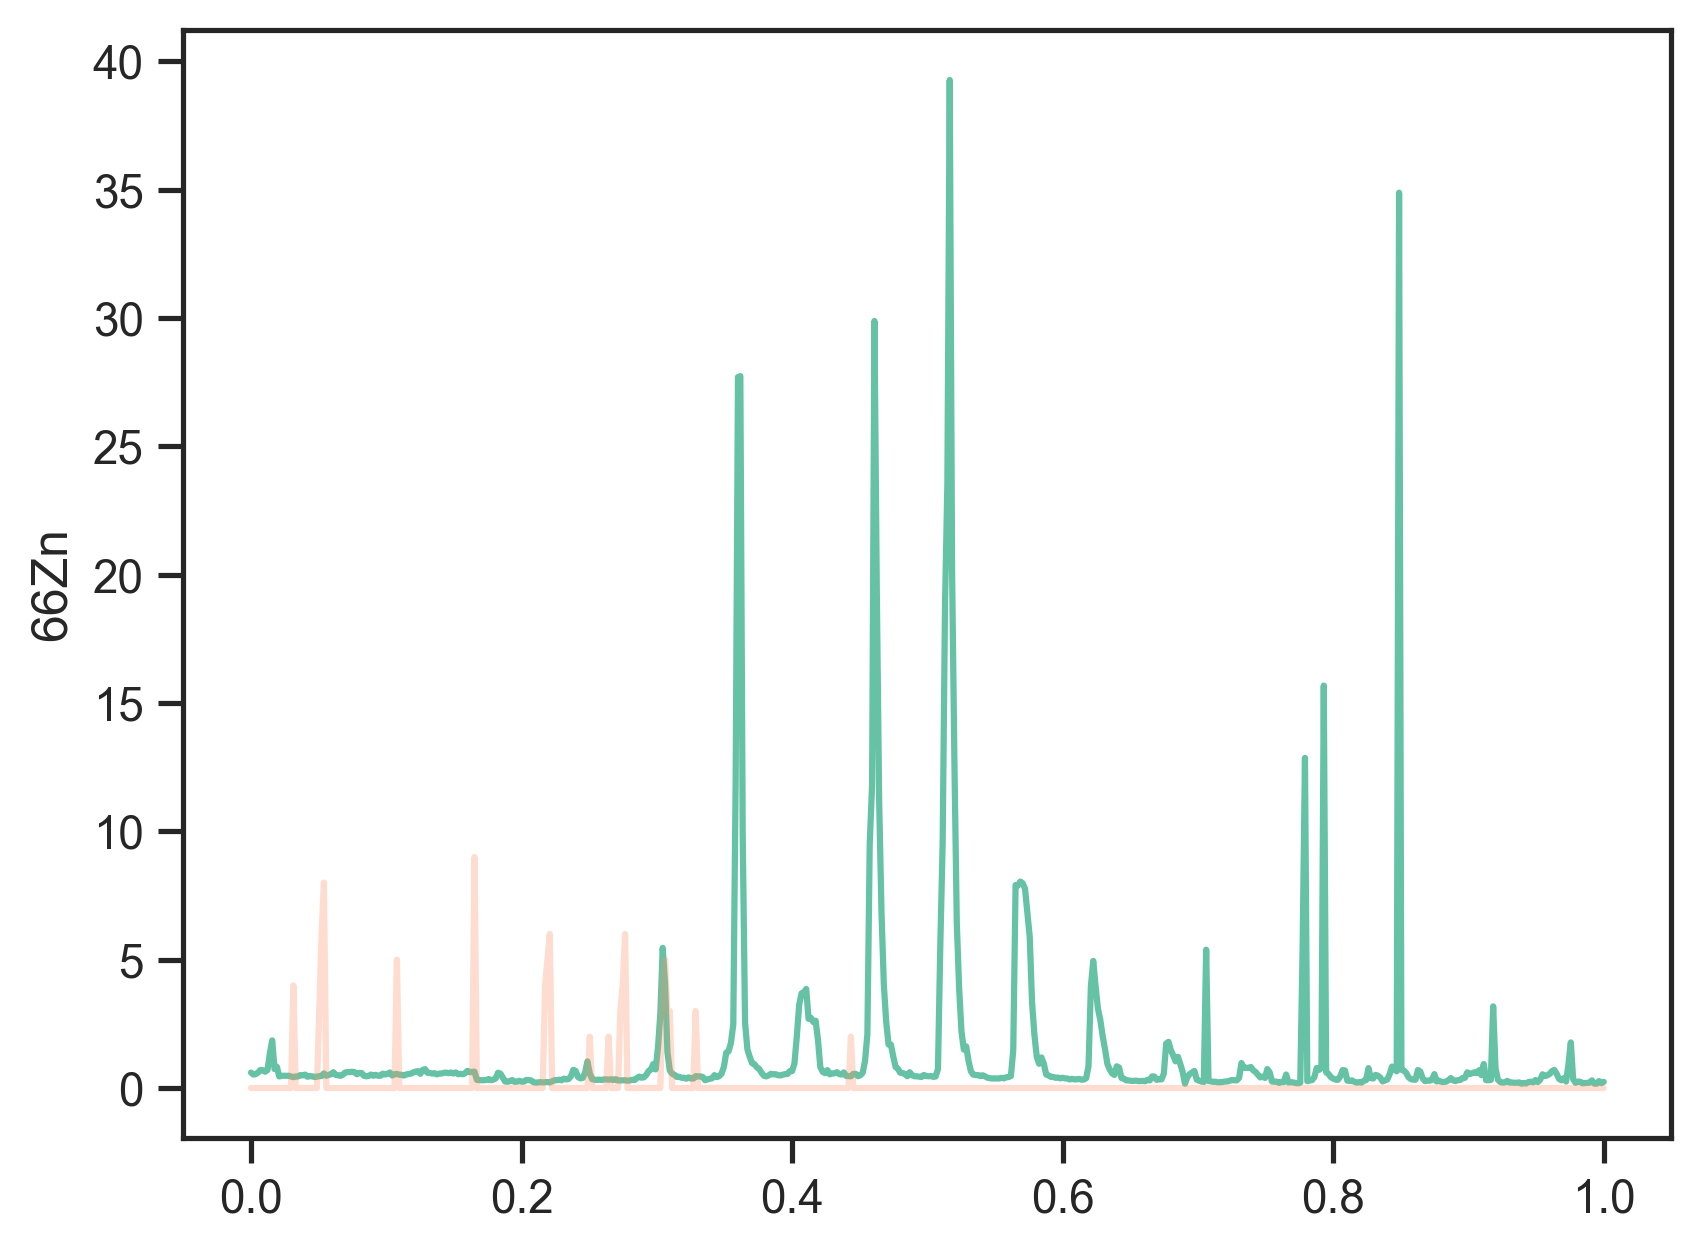

In [9]:
n_samples  = metal_df.shape[0]
linspace = np.linspace(0, 1, n_samples)

sns.lineplot(x=linspace, y="66Zn", data=metal_df)

# plot rpmE col
sns.lineplot(x=linspace, y="rpmE", data=prot_df, alpha=0.3)

# Join the metalloproteome data with the conversion table

In [10]:
# join the data
metal_join_df = metal_df.join(conversion_df, on="Experiment")

x_min = 3
y_min = 1

x_max = 15
y_max = 26


# filter out edges
# if x or y are 0, or x=17 or y=31, remove them.
metal_join_df = metal_join_df.filter((pl.col("x") >= x_min) & (pl.col("y") >= y_min) & (pl.col("x") <= x_max) & (pl.col("y") <=y_max))
prot_df = prot_df.filter((pl.col("x") >= x_min) & (pl.col("y") >= y_min) & (pl.col("x") <= x_max) & (pl.col("y") <= y_max))

metal_join_df

Experiment,25Mg,26Mg,29Si,31P,34S,44Ca,71Ga,73Ge,27Al,47Ti,48Ti,51V,52Cr,55Mn,56Fe,57Fe,59Co,60Ni,63Cu,66Zn,75As,77Se,95Mo,111Cd,115In,118Sn,121Sb,182W,202Hg,208Pb,209Bi,x,y
str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64
"""100to150_2""",2424,3268,358150,658,10318,10690,4,2,1.28963,0.105418,0.23391,0.20744,0.437886,0.994977,1.57962,1.247038,0.036616,0.831977,0.229864,0.30864,0.014489,0.200652,0.081377,0.001336,-13.40308,0.038449,0.004793,12.471815,2.004132,0.00593,4.187315,3,1
"""100to150_3""",2404,3293,353562,737,11082,10791,7,4,1.434155,0.086251,0.26326,0.189714,0.449281,0.965916,1.851357,1.489283,0.035843,0.854022,0.242732,0.302458,0.015648,0.183931,0.081209,0.000779,-13.505967,0.040625,0.005548,12.224868,2.077455,0.006276,3.513492,3,2
"""100to150_4""",2298,3197,346458,704,10499,10289,4,4,1.605376,0.103501,0.246314,0.187535,0.473168,0.947359,2.152927,1.808355,0.035271,0.819974,0.256623,0.304706,0.024341,0.16721,0.077411,0.001781,-13.331345,0.040189,0.005903,12.101366,2.321863,0.006496,3.248776,3,3
"""100to150_5""",2420,3155,341925,690,9885,10242,1,3,1.478341,0.093918,0.238977,0.168423,0.434999,0.926318,1.782944,1.457018,0.03481,0.787764,0.273798,0.312854,0.017386,0.066884,0.079091,0.000668,-13.197517,0.038805,0.005015,13.95364,2.24854,0.006416,3.561624,3,4
"""100to150_6""",2276,3048,329445,753,10192,10398,2,1,1.46177,0.113085,0.252254,0.170305,0.443807,0.90726,1.764867,1.436532,0.036868,0.797316,0.261809,0.34882,0.016227,0.183931,0.078738,0.001002,-13.089512,0.034137,0.004616,12.348343,2.224101,0.00667,3.3691,3,5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""700to800_23""",687,1066,62194,282,3446,4018,0,1,0.968749,0.067557,0.266934,0.100142,0.235307,0.12268,1.015955,0.727855,0.008304,0.205888,0.172192,0.322502,0.021042,0.265612,0.074713,0.000638,-14.964736,0.022933,0.00529,20.51376,1.913082,0.004284,5.048914,15,22
"""700to800_24""",1032,1291,63460,280,3725,5395,1,1,2.75897,0.117098,0.31536,0.101578,0.232665,0.127879,1.182385,0.9304,0.009572,0.23914,0.192601,0.541271,0.017096,0.265612,0.091301,0.000638,-15.408186,0.083402,0.005208,19.536919,1.647375,0.005147,9.42467,15,23
"""700to800_25""",576,809,65263,326,3752,3352,1,1,1.023242,0.076564,0.206102,0.107803,0.262816,0.119358,1.022619,0.776596,0.008429,0.220881,0.171453,0.253877,0.015781,0.132806,0.076556,0.001064,-15.137232,0.026768,0.004394,14.327084,1.753658,0.004305,4.039135,15,24


<Axes: ylabel='66Zn'>

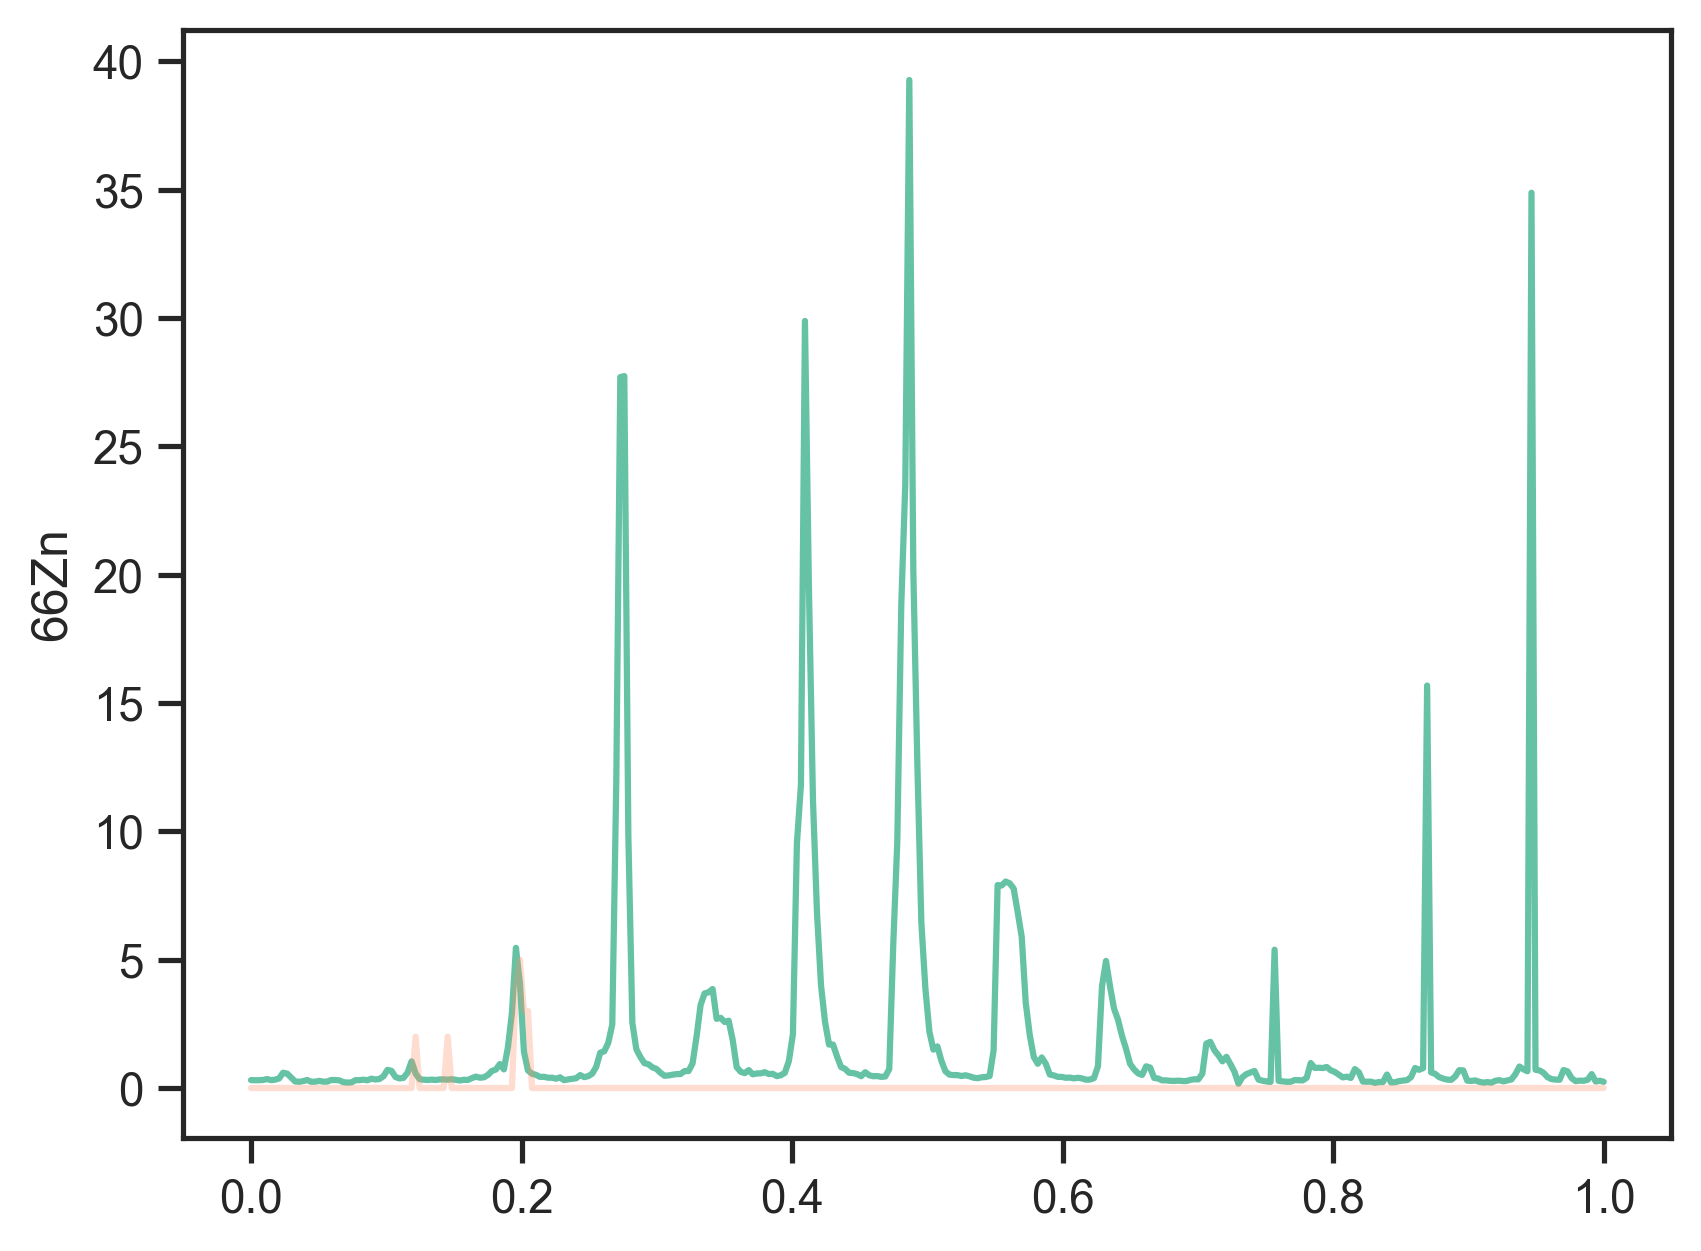

In [11]:
n_samples  = metal_join_df.shape[0]
linspace = np.linspace(0, 1, n_samples)

sns.lineplot(x=linspace, y="66Zn", data=metal_join_df)

# plot rpmE col
sns.lineplot(x=linspace, y="rpmE", data=prot_df, alpha=0.3)

# Import simulation data and conversion tables

In [12]:
# make protein-element mapping
elements = ["FE", "ZN", "MN", "CU", "MO", "NI"]
element_indices = [np.where(element_ids == element)[0][0] for element in elements]


# get name conversion table
gene_name_table = pl.read_csv("external_data/ecocyc_name_conversion.txt", separator="\t")

# rename cols to "Protein ID", "EcoCyc ID", "Accession Number", "Gene name"
gene_name_table.columns = ["Protein ID", "EcoCyc ID", "Accession Number", "Gene name"]

# get corresponding gene name for each protein
gene_name_table = gene_name_table.filter(pl.col("Protein ID").is_in(monomer_ids))

# make a mapping
gene_to_prot_dict = dict(zip(gene_name_table["Gene name"], gene_name_table["Protein ID"]))
prot_to_gene_dict = dict(zip(gene_name_table["Protein ID"], gene_name_table["Gene name"]))

# convert gene_names list to protein id list
detected_protein_ids = [gene_to_prot_dict[gene_name] for gene_name in gene_names if gene_name in gene_to_prot_dict]
# get indices of genes in gene dict
gene_indices = [gene_names.index(gene_name) for gene_name in gene_names if gene_name in gene_to_prot_dict]

# for each protein id, index it in the monomer_ids
detected_protein_idx = [monomer_ids.tolist().index(protein_id) for protein_id in detected_protein_ids]


In [13]:
monomer_to_complex_dict = {}

# create monomer to complex dict
for i, protein_id in enumerate(monomer_ids):
    if protein_id in monomer_ids:

        # get indices where C[:, i] is nonzero
        complex_indices = np.where(C[:, i].toarray() > 0)[0]

        # save complex_id if it doesn't match the protein_id
        complex_id = [protein_ids[idx] for idx in complex_indices if protein_ids[idx] != protein_id]

        # check in Tree if complex_id has parents by checking sum
        complex_parents = [Tree[:, tree_ids.index(complex_id)].sum() for complex_id in complex_id]

        # if complex_id doesn't have parents, select it
        for j, complex_id_idx in enumerate(complex_id):
            if complex_parents[j] == 0:
                monomer_to_complex_dict[protein_id] = complex_id[j]

                # if len(complex_id) > 1:
                    # print(f"Multiple complex ids found for protein: {protein_id}, complex ids: {complex_id}. Picked {complex_id[j]}")




In [14]:
elements = ["FE", "ZN", "MN", "CU", "MO", "NI"]
element_indices = [np.where(element_ids == element)[0][0] for element in elements]

sim_prot_metal = np.diag(total_counts_min.mean(axis=0) @ C) @ P @ E[:, element_indices]

# divide by col sums
sim_prot_metal = sim_prot_metal / sim_prot_metal.sum(axis=0)

sim_prot_metal_df = pl.DataFrame(sim_prot_metal, schema=elements)
sim_prot_metal_df = sim_prot_metal_df.with_columns(pl.Series(name="Protein ID", values=monomer_ids))
sim_prot_metal_df = sim_prot_metal_df.with_columns(pl.Series(name="Gene",
                                                             values=[prot_to_gene_dict[protein_id]  if protein_id in prot_to_gene_dict else "None" for protein_id in sim_prot_metal_df["Protein ID"]]))

# only include genes found in the experimental data
sim_prot_metal_df = sim_prot_metal_df.filter(pl.col("Gene").is_in(gene_names))

# use monomer_to_complex_dict to add complex id column by using polars replace
sim_prot_metal_df = sim_prot_metal_df.with_columns(pl.Series(name="Complex ID", values=sim_prot_metal_df["Protein ID"].replace(monomer_to_complex_dict)))


sim_prot_metal_df

FE,ZN,MN,CU,MO,NI,Protein ID,Gene,Complex ID
f64,f64,f64,f64,f64,f64,str,str,str
0.0,0.0,0.0,0.0,0.0,0.0,"""1-PFK-MONOMER""","""fruK""","""1-PFK"""
0.0,0.0,0.0,0.0,0.0,0.0,"""2-ISOPROPYLMALATESYN-MONOMER""","""leuA""","""2-ISOPROPYLMALATESYN-MONOMER"""
0.0,0.0,0.0,0.0,0.0,0.0,"""2-OCTAPRENYL-METHOXY-BENZOQ-ME…","""ubiE""","""CPLX0-8301"""
0.0,0.0,0.0,0.0,0.0,0.0,"""3-CH3-2-OXOBUTANOATE-OH-CH3-XF…","""panB""","""3-METHYL-2-OXOBUT-OHCH3XFER-CP…"
0.0,0.0,0.0,0.0,0.0,0.0,"""3-ISOPROPYLMALDEHYDROG-MONOMER""","""leuB""","""3-ISOPROPYLMALDEHYDROG-CPLX"""
…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,0.0,0.0,0.0,"""YJJK-MONOMER""","""ettA""","""YJJK-MONOMER"""
0.0,0.0,0.0,0.0,0.0,0.0,"""YLIB-MONOMER""","""gsiB""","""ABC-49-CPLX"""
0.0,0.0,0.0,0.0,0.0,0.0,"""YNEA-MONOMER""","""lsrB""","""ABC-58-CPLX"""


# Plot unprocessed data

In [15]:
metal_join_df.pivot(values="66Zn", index="x", on="y")

x,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
3,0.30864,0.302458,0.304706,0.312854,0.34882,0.306251,0.325077,0.373406,0.59511,0.560968,0.40881,0.255535,0.242751,0.270005,0.310607,0.242048,0.247808,0.278996,0.247246,0.249635,0.313842,0.309643,0.298524,0.227017,0.211844,0.217182
4,0.305354,0.304674,0.323886,0.301443,0.363503,0.333748,0.351601,0.4594,0.707655,0.666845,0.428284,0.374045,0.394618,0.600359,1.037044,0.567032,0.34565,0.323206,0.314875,0.326267,0.312325,0.334258,0.335788,0.324737,0.342419,0.316405
5,0.294378,0.31995,0.313326,0.382496,0.444118,0.402523,0.415617,0.506204,0.663656,0.720045,0.933284,0.725129,1.586023,2.92024,5.459695,4.057565,1.410191,0.683377,0.556273,0.51252,0.432718,0.436569,0.400828,0.400058,0.362931,0.415617
6,0.305684,0.335323,0.356893,0.380635,0.503385,0.424241,0.460865,0.558321,0.824013,1.376102,1.429034,1.76077,2.47371,11.928867,27.698531,27.73651,9.882995,2.543277,1.506182,1.210171,0.968352,0.926911,0.807096,0.743776,0.596652,0.479021
7,0.489845,0.517898,0.541275,0.544911,0.657124,0.660587,0.958451,2.005139,3.234573,3.686185,3.732107,3.857236,2.695349,2.735196,2.572162,2.622925,1.87158,0.812114,0.631495,0.579718,0.697127,0.533309,0.56673,0.571233,0.617122,0.543353
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11,0.323948,0.329274,0.383994,0.851554,3.961334,4.951636,3.963274,3.09282,2.657525,2.025596,1.519912,0.942117,0.72443,0.571158,0.509899,0.8455,0.796588,0.3915,0.369709,0.297799,0.297799,0.280366,0.275766,0.287146,0.273345,0.269229
12,0.316809,0.341714,0.335808,0.558408,1.732139,1.798396,1.47303,1.275046,1.040094,1.214959,0.931737,0.633894,0.168417,0.422074,0.544031,0.604626,0.665731,0.326052,0.283947,0.254935,0.237221,5.388663,0.276758,0.26007,0.242098,0.243895
13,0.31031,0.303271,0.297111,0.399769,0.972921,0.782549,0.789002,0.778443,0.818922,0.690151,0.625914,0.51856,0.413848,0.443766,0.392437,0.738257,0.610369,0.250769,0.24549,0.248423,0.198562,0.232585,0.231998,0.525893,0.21616,0.226718


    ## Filter out edges

In [16]:
# For each protein, pivot and do some filtering

for protein in gene_names:
    prot_pivot = prot_df.pivot(values=protein, index="x", on="y", ).to_numpy()[:, 1:]

    # create boolean array
    prot_mask = prot_pivot > 0

    # find number of neighbours per well
    footprint = np.array([[1,1,1],
                          [1,0,1],
                          [1,1,1]])

    f = lambda x: x.sum()

    results = ndimage.generic_filter(prot_mask, f, footprint=footprint, mode="constant", cval=0)

    # get AND of the two
    prot_pivot_true_mask = prot_mask & results

    # dont zero if it would remove all the data
    if prot_pivot_true_mask.sum() > 0:
        prot_pivot[~prot_pivot_true_mask] = 0

    # set column as flattened pivot
    prot_df = prot_df.with_columns(pl.Series(name=protein, values=prot_pivot.flatten()))



In [17]:
# for specific wells with extreme outlier values, zero all metal masses.
problem_wells = [[11, 7], [12, 7], [9, 21]]
disable_wells = True

# loop through metal cols, pivot, and zero out the problem wells
if disable_wells == True:
    for metal in metals:
        metal_pivot = metal_join_df.pivot(values=metal, index="x", on="y", ).to_numpy()[:, 1:]
    
        # set to minimum value
        for well in problem_wells:
            metal_pivot[well[0], well[1]] = np.median(metal_pivot)
    
        # set column as flattened pivot
        metal_join_df = metal_join_df.with_columns(pl.Series(name=metal, values=metal_pivot.flatten()))


In [18]:
from matplotlib.colors import LogNorm


# Check out some data

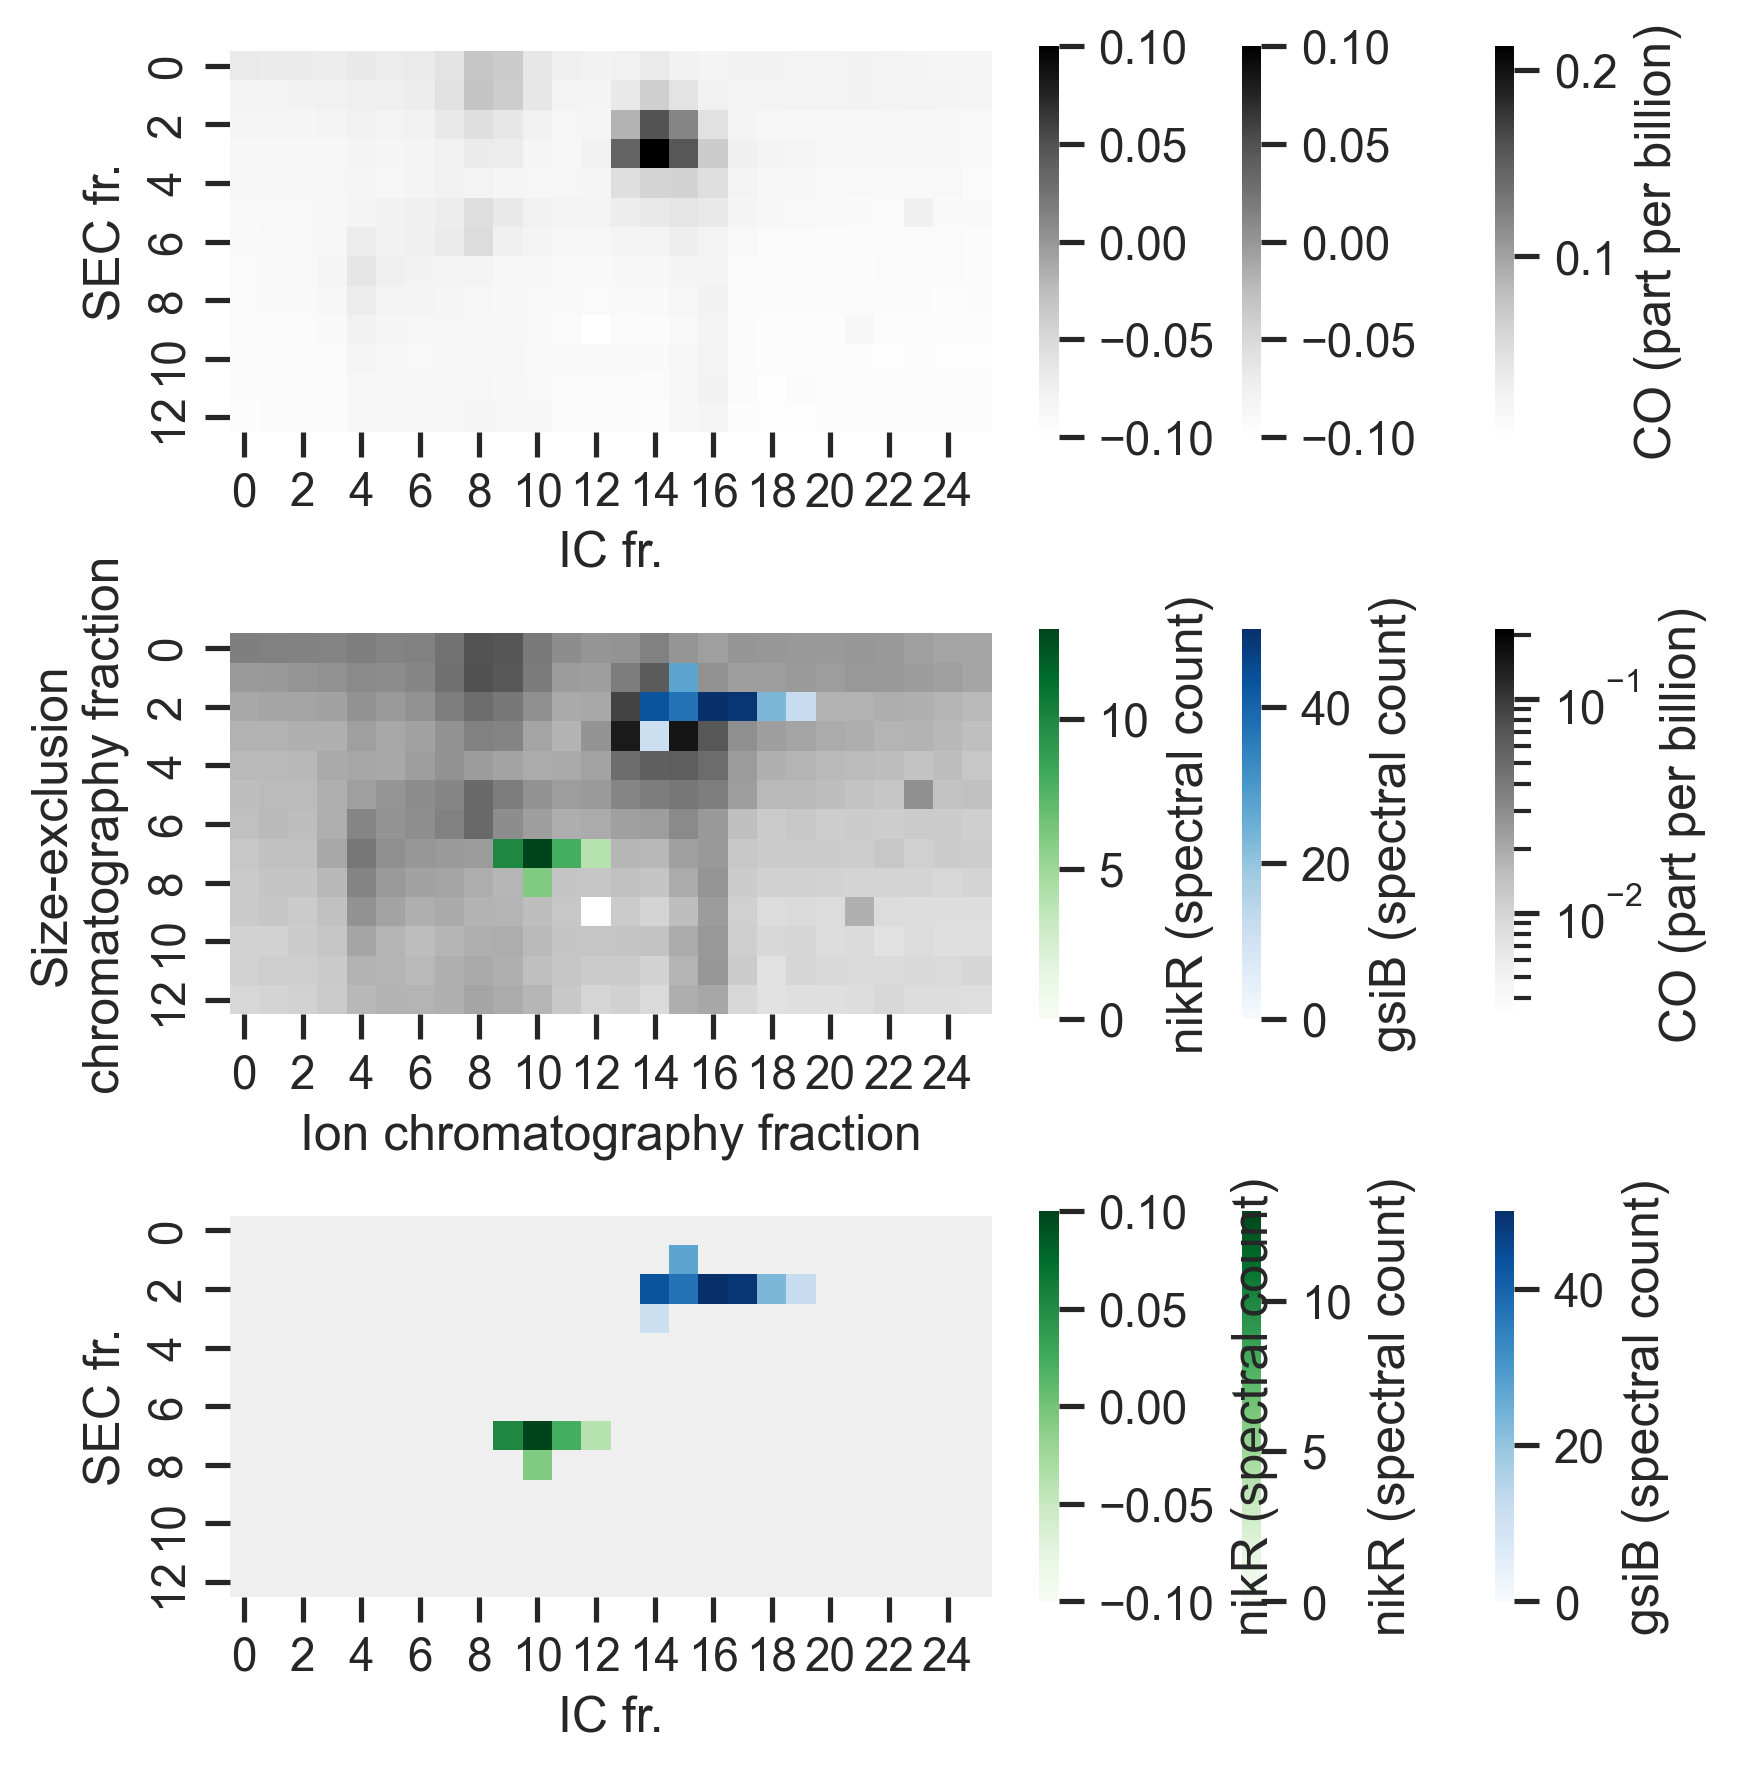

In [29]:
from matplotlib.colors import LogNorm
# plt.figure(figsize=(12, 6))

f, ax = plt.subplots(3,1, figsize=(6, 6))

gene = "gsiB"
gene2 = "nikR"
metal = "59Co"
metal_translated = isotope_element_mapping[metal]

# heatmap of 56Fe data against x and y
sns.heatmap(metal_join_df.pivot(values=metal, index="x", on="y", )[:, 1:], cmap="Grays", square=True, cbar=True,
            # norm=LogNorm(), 
            cbar_kws={'label': f'{metal_translated} (part per billion)'}, ax=ax[0])
sns.heatmap(prot_df.pivot(values=gene, index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene,index="x", on="y", ) < 1000).to_numpy()[:, 1:],
            cmap="Grays", square=True, cbar=True, vmin=0,  cbar_kws={'label': f' '}, ax=ax[0])
sns.heatmap(prot_df.pivot(values=gene, index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene, index="x", on="y",) < 1000).to_numpy()[:, 1:],
            cmap="Grays", square=True, cbar=True, vmin=0,  cbar_kws={'label': f' '}, ax=ax[0])

# add x and y labels
ax[0].set_ylabel("SEC fr.")
ax[0].set_xlabel("IC fr.")


sns.heatmap(metal_join_df.pivot(values=metal, index="x", on="y", )[:, 1:], cmap="Grays", square=True,
            cbar=True, norm=LogNorm(), cbar_kws={'label': f'{metal_translated} (part per billion)'}, ax=ax[1])
sns.heatmap(prot_df.pivot(values=gene, index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene, index="x", on="y",) < 1).to_numpy()[:, 1:],
            cmap="Blues", square=True, cbar=True, vmin=0,  cbar_kws={'label': f'{gene} (spectral count)'}, ax=ax[1])
sns.heatmap(prot_df.pivot(values=gene2, index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene2, index="x", on="y", ) < 1).to_numpy()[:, 1:],
            cmap="Greens", square=True, cbar=True, vmin=0,  cbar_kws={'label': f'{gene2} (spectral count)'}, ax=ax[1])

# add x and y labels
ax[1].set_ylabel("Size-exclusion\nchromatography fraction")
ax[1].set_xlabel("Ion chromatography fraction")

sns.heatmap(prot_df.pivot(values=gene, index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene, index="x", on="y", ) < 1).to_numpy()[:, 1:],
            cmap="Blues", square=True, cbar=True, vmin=0,  cbar_kws={'label': f'{gene} (spectral count)'}, ax=ax[2])
sns.heatmap(prot_df.pivot(values=gene2,index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene2,index="x", on="y", ) < 1).to_numpy()[:, 1:],
            cmap="Greens", square=True, cbar=True, vmin=0,  cbar_kws={'label': f'{gene2} (spectral count)'}, ax=ax[2])
sns.heatmap(prot_df.pivot(values=gene2, index="x", on="y", )[:, 1:], mask=(prot_df.pivot(values=gene2, index="x", on="y", ) < 5000).to_numpy()[:, 1:],
            cmap="Greens", square=True, cbar=True, vmin=0,  cbar_kws={'label': f'{gene2} (spectral count)'}, ax=ax[2])

# add x and y labels
ax[2].set_ylabel("SEC fr.")
ax[2].set_xlabel("IC fr.")
ax[2].grid(False)

# set a gray background for ax[2]
ax[2].set_facecolor("#EFEFEF")

# add subplot titles
# ax[0].set_title(f"Zn-66 distribution")
# ax[1].set_title(f"{gene} distribution overlaid on {metal_translated}")

plt.tight_layout()

# save as png and svg
# plt.savefig("figures/cu.png")


x,y,Protein count
i64,i64,i64
3,1,87
3,2,71
3,3,68
3,4,103
3,5,64
…,…,…
15,22,0
15,23,0
15,24,19


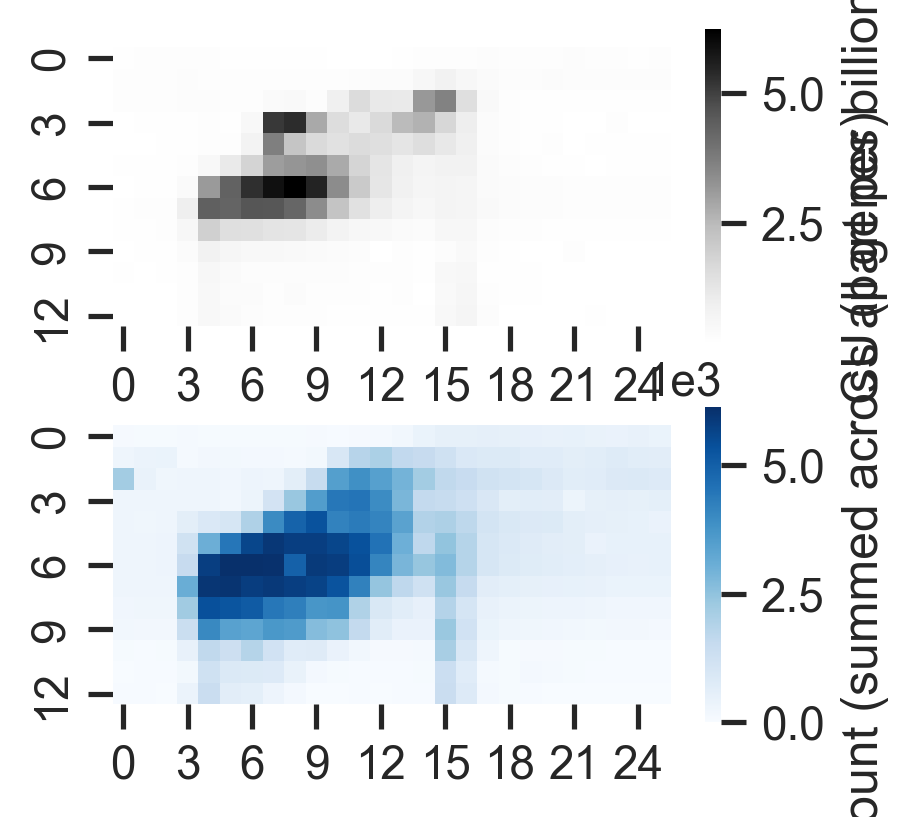

In [27]:
f, ax = plt.subplots(2,1, figsize=(3, 3))


# heatmap of 56Fe data against x and y
sns.heatmap(metal_join_df.pivot(values=metal, index="x", on="y", )[:, 1:], cmap="Grays", square=True, cbar=True,
            # norm=LogNorm(), 
            cbar_kws={'label': f'{metal_translated} (part per billion)'}, ax=ax[0])

# aggregate protein counts and heatmap
prot_agg = prot_df.drop("Experiment").unpivot(index=["x", "y"], on=gene_names, variable_name="Gene", value_name="Protein count")\
.group_by(["x","y"]).agg(pl.sum("Protein count")).sort(["x", "y"])

# create heatmap 
sns.heatmap(prot_agg.pivot(values="Protein count", index="x", on="y", )[:, 1:],
            cmap="Blues", square=True, cbar=True, vmin=0000,  cbar_kws={'label': f'Protein count (summed across all genes)'},ax=ax[1]
            # norm=LogNorm(vmin=1000)
            )
# prot_agg.pivot(values="Protein count", index="x", on="y", )
prot_agg

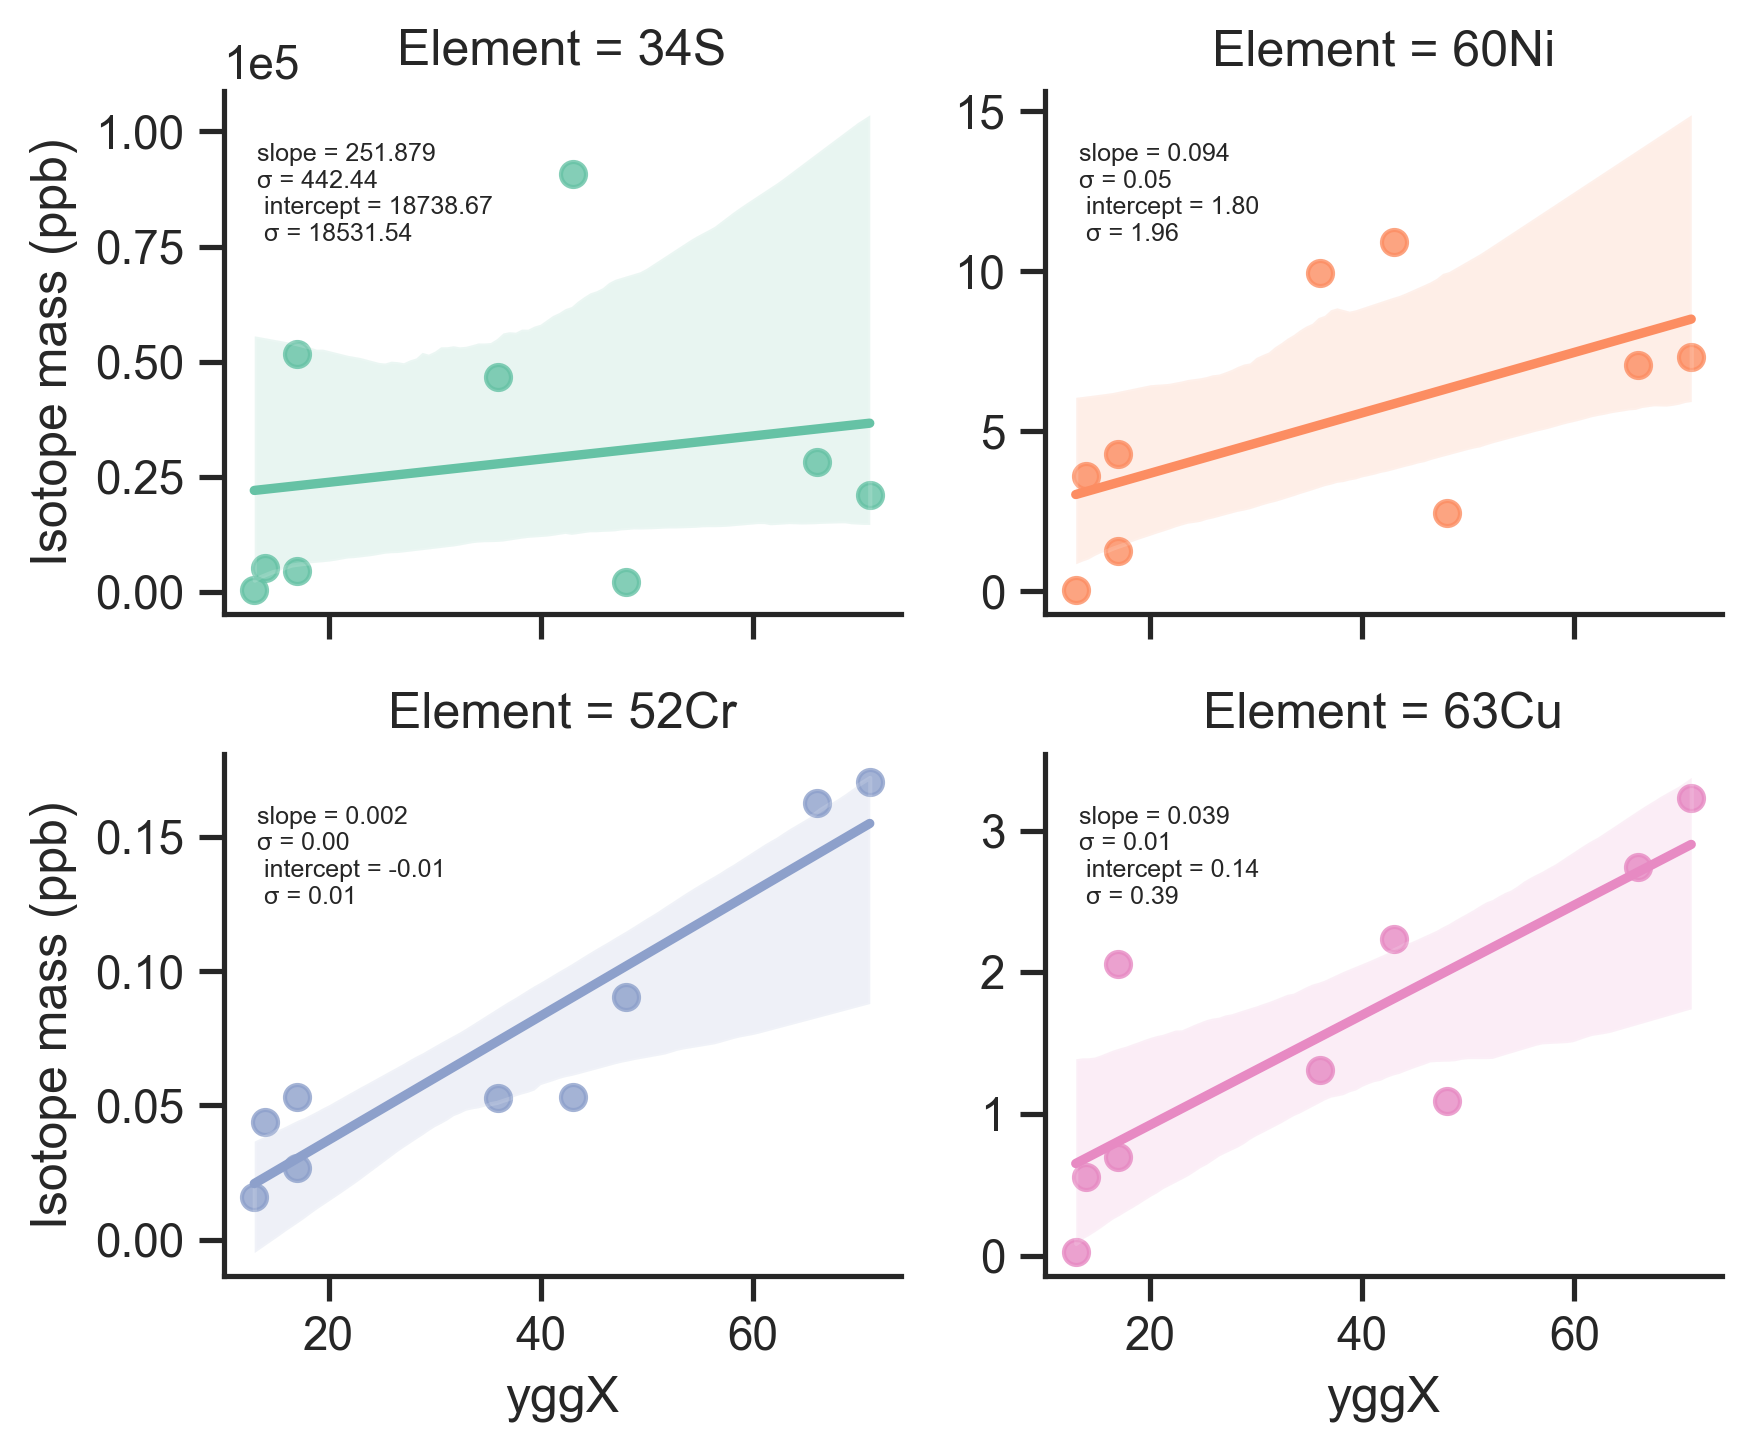

In [152]:
gene = "yggX"
elements = ["34S", "60Ni", "52Cr","63Cu"]

subset = prot_df.select(["x", "y", gene]).filter(pl.col(gene) > 1)

subset = metal_join_df.select(["x", "y",] + elements).join(subset, on=["x", "y"], how="inner")


# divide 182W by 1000
if "182W" in subset.columns:
    subset = subset.with_columns(pl.col("182W") / 1000)
    
# subtract minimum value from each metal column
for element in elements:
    subset = subset.with_columns(pl.col(element) - 0.95 * pl.col(element).min())
    
subset = subset.melt(id_vars=["x", "y", gene], variable_name="Element", value_name="Isotope mass (ppb)")

# normalize gene by maximum, normalize isotope mass by maximum, 
# subset = subset.with_columns(pl.col(gene) / pl.col(gene).max())
# subset = subset.with_columns((pl.col("Isotope mass (ppb)") / pl.col("Isotope mass (ppb)").max()).alias("Isotope mass (normalized)"))

g = sns.lmplot(x=gene, y="Isotope mass (ppb)", hue="Element", data=subset, height = 2.5, aspect = 1.2,
                col="Element", col_wrap=2, sharey=False
               )
# 
def annotate_slope_std(data, **kws):
    x = data[gene]
    y = data["Isotope mass (ppb)"]
    slope, intercept = np.polyfit(x, y, 1)
    resid_std = np.std(y - (slope * x + intercept))
    # calculate std dev of slope
    slope_std = resid_std / np.sqrt(np.sum((x - np.mean(x))**2))
    intercept_std = resid_std * np.sqrt(1/len(x) + np.mean(x)**2 / np.sum((x - np.mean(x))**2))

    ax = plt.gca()
    ax.text(0.05, 0.90, f"slope = {slope:.3f}\nσ = {slope_std:.2f} \n intercept = {intercept:.2f} \n σ = {intercept_std:.2f}"
            , transform=ax.transAxes, fontsize=6,va="top")

g.map_dataframe(annotate_slope_std)


# for ax in g.axes.flat:
#     ax.set_aspect('equal', adjustable='datalim')
# 
# plt.axis('equal')

# # Make sure both axes include 0
# g.set(xlim=(-0.1, 1.1), ylim=(-0.1, 1.1))

# Large scale regression.

In [101]:
# melt prot_df and remove zero counts.
prot_melted = prot_df.drop(pl.col("Experiment")).melt(id_vars=["x", "y"], variable_name="Gene", value_name="Protein count").filter(pl.col("Protein count") > 0)

# join with metal_join_df as left join
prot_melted = prot_melted.join(metal_join_df.drop(["Experiment", "115In"]), on=["x", "y"], how="left")

# divide W by 1000
if "182W" in prot_melted.columns:
    prot_melted = prot_melted.with_columns(pl.col("182W") / 1000)
    
elements = ["55Mn","56Fe", "60Ni", "66Zn", "95Mo", "182W", "59Co", "52Cr"]

# select just these elements for now.
prot_melted = prot_melted.select(["Gene", "Protein count"] + elements)

# melt again. 
prot_melted = prot_melted.melt(id_vars=["Gene", "Protein count"], variable_name="Element", value_name="Isotope mass (ppb)")

# for each gene, element, get the minimum isotope mass, and subtract it from the isotope mass column to get rid of background noise. Do this by grouping by gene and element, getting the minimum, and then joining back on gene and element to subtract.
min_isotope_mass = prot_melted.group_by(["Gene", "Element"]).agg(pl.col("Isotope mass (ppb)").min().alias("Min isotope mass"))
prot_melted = prot_melted.join(min_isotope_mass, on=["Gene", "Element"], how="left").with_columns((pl.col("Isotope mass (ppb)") - 0.95 * pl.col("Min isotope mass")).alias("Isotope mass (ppb)")).drop("Min isotope mass")


print(prot_melted)
# .group_by(["Gene", "Element"]).agg(pl.corr("Protein count", "Isotope mass (ppb)")).sort("corr", descending=True)

shape: (204_392, 4)
┌──────┬───────────────┬─────────┬────────────────────┐
│ Gene ┆ Protein count ┆ Element ┆ Isotope mass (ppb) │
│ ---  ┆ ---           ┆ ---     ┆ ---                │
│ str  ┆ i64           ┆ str     ┆ f64                │
╞══════╪═══════════════╪═════════╪════════════════════╡
│ tufB ┆ 2             ┆ 55Mn    ┆ 0.284372           │
│ tufB ┆ 4             ┆ 55Mn    ┆ 0.578368           │
│ tufB ┆ 4             ┆ 55Mn    ┆ 0.576991           │
│ tufB ┆ 4             ┆ 55Mn    ┆ 0.504083           │
│ tufB ┆ 3             ┆ 55Mn    ┆ 0.507602           │
│ …    ┆ …             ┆ …       ┆ …                  │
│ ygaC ┆ 2             ┆ 52Cr    ┆ 0.018047           │
│ ycaK ┆ 2             ┆ 52Cr    ┆ 0.015293           │
│ miaA ┆ 2             ┆ 52Cr    ┆ 0.015049           │
│ fruK ┆ 2             ┆ 52Cr    ┆ 0.014585           │
│ ubiF ┆ 2             ┆ 52Cr    ┆ 0.016615           │
└──────┴───────────────┴─────────┴────────────────────┘


In [102]:
# --- 2. UPDATED regression function ---
# Now returns the p-value for the slope as well
def get_regression_stats(cols: list[pl.Series]) -> pl.Series:
    y_series, x_series = cols
    
    # Base dictionary for returning nulls
    null_result = {"slope": None, "intercept": None, "r_squared": None, "slope_std_err": None, "intercept_std_err": None, "slope_t_stat": None, "p_value_slope": None}

    if y_series.len() < 2:
        return pl.Series([null_result])
        
    if x_series.n_unique() == 1:
        # For constant x, slope is 0, which is not statistically significant
        result = null_result.copy()
        result.update({"slope": 0.0, "intercept": y_series.mean(), "r_squared": 0.0, "p_value_slope": 1.0, "intercept_std_err": y_series.std()})
        return pl.Series([result])
    
    x_with_const = sm.add_constant(x_series.to_numpy(), prepend=True)
    y = y_series.to_numpy()
    model = sm.OLS(y, x_with_const).fit()

    # if slope is negative, return p value of 1
    if model.params[1] < 0:
        pval = 1.0
    else:
        pval = model.pvalues[1] / 2

    return pl.Series([{
        "slope": model.params[1],
        "intercept": model.params[0],
        "r_squared": model.rsquared,
        "slope_std_err": model.bse[1],
        "intercept_std_err": model.bse[0],
        "slope_t_stat": model.tvalues[1],
        "p_value_slope": pval  # <-- Extract the p-value here
    }])

# --- 3. UPDATED Schema and Aggregation Logic ---
# Add the new field for the p-value
regression_output_schema = pl.Struct([
    pl.Field("slope", pl.Float64),
    pl.Field("intercept", pl.Float64),
    pl.Field("r_squared", pl.Float64),
    pl.Field("slope_std_err", pl.Float64),
    pl.Field("intercept_std_err", pl.Float64),
    pl.Field("slope_t_stat", pl.Float64),
    pl.Field("p_value_slope", pl.Float64) # <-- Add schema field
])

regression_results = (
    prot_melted.group_by("Gene", "Element")
    .agg(
        pl.map_batches(
            exprs=[pl.col("Isotope mass (ppb)"), pl.col("Protein count")],
            function=get_regression_stats,
            return_dtype=regression_output_schema
        ).alias("regression_results"),
        pl.count().alias("n_points")
    )
    .with_columns(
        pl.col("regression_results").list.get(0)
    )
    .unnest("regression_results")
)

In [103]:
# if regression slope is positive with 0 not in the confidence interval, create new col with true
regression_results = regression_results.with_columns((
    (pl.col("slope") > 0) & (pl.col("slope") - 1.96 * pl.col("slope_std_err") > 0)).alias("positive_slope_confident")
)

# if 0 is in the confidence interval of intercept, create new col with true
regression_results = regression_results.with_columns(
    (((pl.col("intercept") - 1.96 * pl.col("intercept_std_err")) < 0) & ((pl.col("intercept") + 1.96 * pl.col("intercept_std_err")) > 0)).alias("intercept_confident_zero"))

regression_results.filter(pl.col("Gene") == "modA")

Gene,Element,slope,intercept,r_squared,slope_std_err,intercept_std_err,slope_t_stat,p_value_slope,n_points,positive_slope_confident,intercept_confident_zero
str,str,f64,f64,f64,f64,f64,f64,f64,u32,bool,bool
"""modA""","""60Ni""",-0.129061,5.835688,0.440344,0.0594,1.704707,-2.172757,1.0,8,false,false
"""modA""","""59Co""",-0.001579,0.085633,0.26661,0.001069,0.030678,-1.476885,1.0,8,false,false
"""modA""","""182W""",0.016102,-0.181214,0.922932,0.0019,0.054515,8.476637,0.000074,8,true,false
"""modA""","""55Mn""",0.026564,0.028931,0.204012,0.021422,0.614774,1.240083,0.13062,8,false,true
"""modA""","""66Zn""",-0.026837,2.363424,0.060296,0.043252,1.241277,-0.620477,1.0,8,false,true
"""modA""","""52Cr""",-0.004323,0.212262,0.712277,0.001122,0.032191,-3.854009,1.0,8,false,false
"""modA""","""56Fe""",-0.007181,0.588155,0.157987,0.006768,0.194226,-1.06103,1.0,8,false,false
"""modA""","""95Mo""",0.020155,-0.206043,0.925153,0.00234,0.067167,8.611825,0.000067,8,true,false


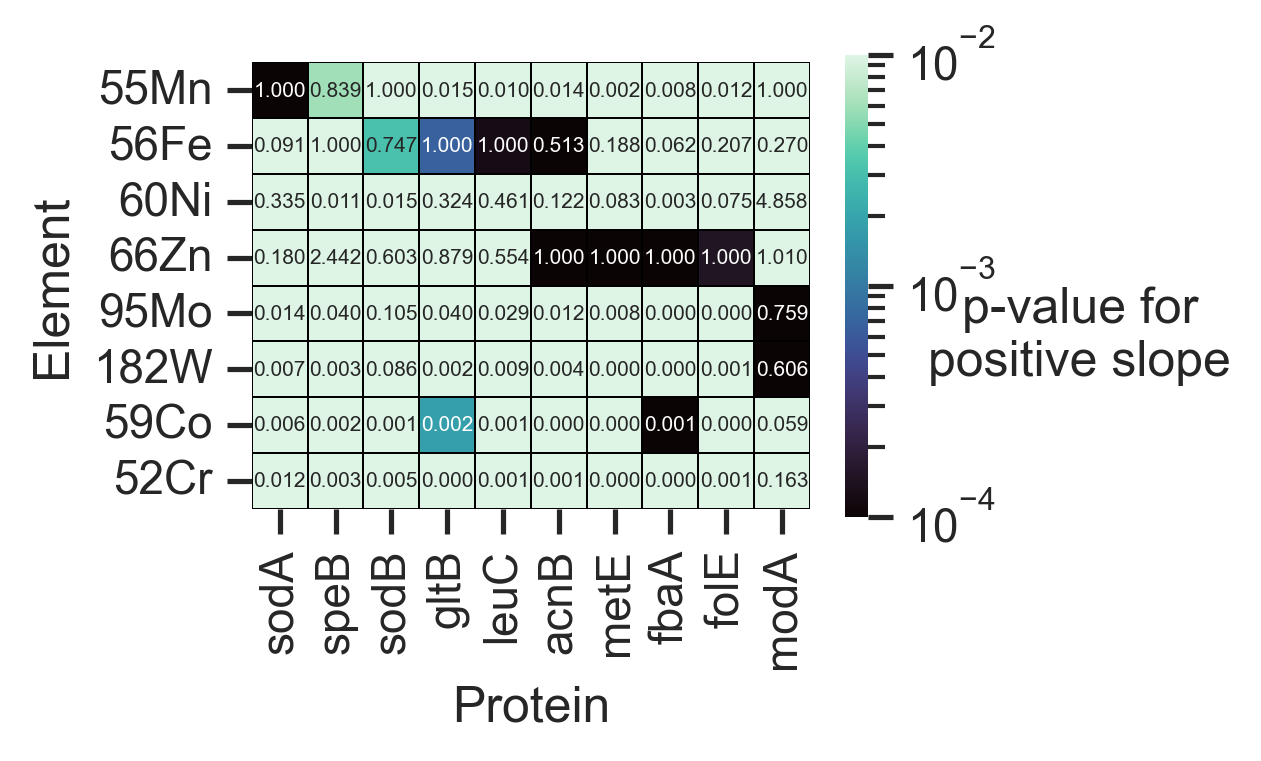

In [104]:
genes = ["sodA", "speB", "sodB","gltB", "leuC","acnB", "metE",  "fbaA", "folE",  "modA",] #glpK removed

# create heatmap of positive slope and intercept confident
heatmap_data = regression_results.filter(pl.col("Gene").is_in(genes)).pivot(values="p_value_slope", index="Element", on="Gene").select(["Element"] + genes)


# create a column that uses the index of elements list
element_mapping_dict = {element: index for index, element in enumerate(elements)}

heatmap_data = heatmap_data.with_columns(pl.col("Element").replace(element_mapping_dict).alias("Element index"))

# sort by element index
heatmap_data = heatmap_data.sort("Element index").drop("Element index")

# create heatmap of positive slope and intercept confident
heatmap_slopes = regression_results.filter(pl.col("Gene").is_in(genes)).pivot(values="slope", index="Element", on="Gene").select(["Element"] + genes)

# divide each slope column by max
for gene in genes:
    heatmap_slopes = heatmap_slopes.with_columns((pl.col(gene) / pl.col(gene).max()).abs())

heatmap_slopes = heatmap_slopes.with_columns(pl.col("Element").replace(element_mapping_dict).alias("Element index"))

# sort by element index
heatmap_slopes = heatmap_slopes.sort("Element index").drop("Element index")


plt.figure(figsize=(3, 2))

# plot heatmap with x as gene and y as element, and color as positive_slope_confident
sns.heatmap(heatmap_data.to_pandas().set_index("Element"), cmap="mako", cbar=True, square=True, norm=LogNorm(vmin=0.0001, vmax=0.01), cbar_kws={'label': 'p-value for\npositive slope'},
            annot=heatmap_slopes.to_pandas().set_index("Element"), annot_kws={"size": 5}, fmt=".3f",
            linewidth=0.1, linecolor="k"
            )

# add x axis label
plt.xlabel("Protein")

# put colorbar on top
plt.gca().collections[0].colorbar.set_label('p-value for\npositive slope', rotation=0, labelpad=20)

# save as svg
plt.savefig("figures/regression_heatmap.svg")


    # Do individual plots for sodA and modA

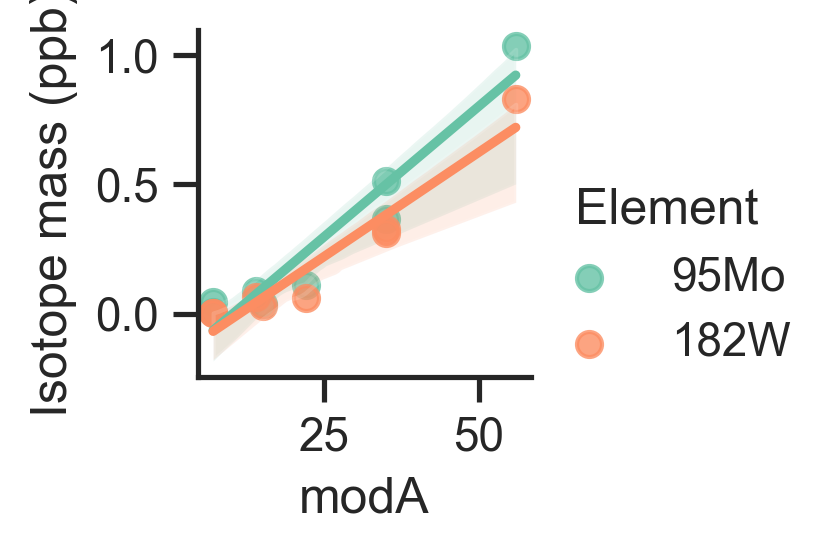

In [105]:
gene = "modA"
elements = [ "95Mo","182W"]

subset = prot_df.select(["x", "y", gene]).filter(pl.col(gene) > 1)

subset = metal_join_df.select(["x", "y",] + elements).join(subset, on=["x", "y"], how="inner")


# divide 182W by 1000
if "182W" in subset.columns:
    subset = subset.with_columns(pl.col("182W") / 1000)
    
# # subtract minimum value from each metal column
for element in elements:
    subset = subset.with_columns(pl.col(element) - 0.95 * pl.col(element).min())
    
subset = subset.melt(id_vars=["x", "y", gene], variable_name="Element", value_name="Isotope mass (ppb)")

# # normalize gene by maximum, normalize isotope mass by maximum, 
# subset = subset.with_columns(pl.col(gene) / pl.col(gene).max())

# for each element, normalize isotope mass by maximum. use group_by and join.
element_max = subset.group_by("Element").agg(pl.col("Isotope mass (ppb)").max().alias("Element max"))
subset = subset.join(element_max, on="Element", how="left").with_columns((pl.col("Isotope mass (ppb)") / pl.col("Element max")).alias("Isotope mass (normalized)")).drop("Element max")

g = sns.lmplot(x=gene, y="Isotope mass (ppb)", hue="Element", data=subset, height = 2, aspect = 1.1,
                # col="Element", col_wrap=2, sharey=False
               )


# save as svg
plt.savefig("figures/modA_mo_w.svg", transparent=True)

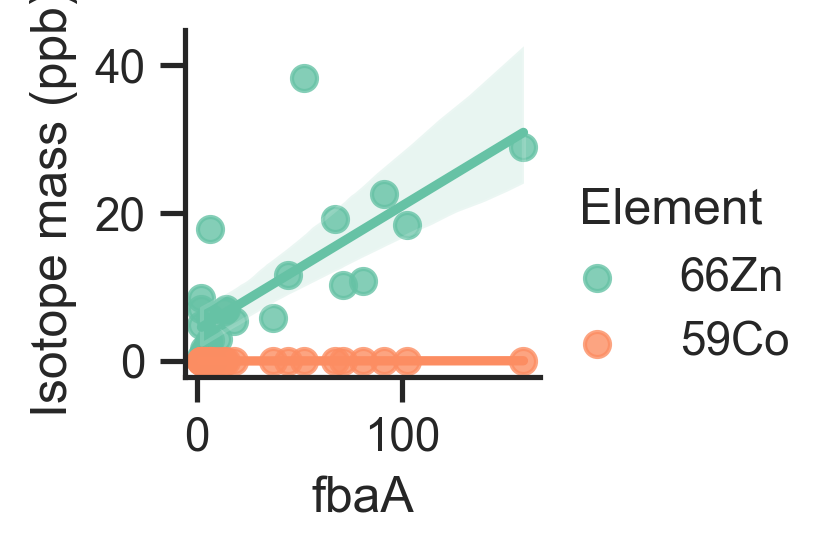

In [106]:
gene = "fbaA"
elements = [ "66Zn","59Co"]

subset = prot_df.select(["x", "y", gene]).filter(pl.col(gene) > 1)

subset = metal_join_df.select(["x", "y",] + elements).join(subset, on=["x", "y"], how="inner")


# divide 182W by 1000
if "182W" in subset.columns:
    subset = subset.with_columns(pl.col("182W") / 1000)

# # subtract minimum value from each metal column
for element in elements:
    subset = subset.with_columns(pl.col(element) - 0.95 * pl.col(element).min())

subset = subset.melt(id_vars=["x", "y", gene], variable_name="Element", value_name="Isotope mass (ppb)")

# # normalize gene by maximum, normalize isotope mass by maximum,
# subset = subset.with_columns(pl.col(gene) / pl.col(gene).max())

# for each element, normalize isotope mass by maximum. use group_by and join.
element_max = subset.group_by("Element").agg(pl.col("Isotope mass (ppb)").max().alias("Element max"))
subset = subset.join(element_max, on="Element", how="left").with_columns((pl.col("Isotope mass (ppb)") / pl.col("Element max")).alias("Isotope mass (normalized)")).drop("Element max")

g = sns.lmplot(x=gene, y="Isotope mass (ppb)", hue="Element", data=subset, height = 2, aspect = 1.1,
                # col="Element", col_wrap=2, sharey=False
               )


# save as svg
plt.savefig("figures/fbaA_zn_co.svg", transparent=True)

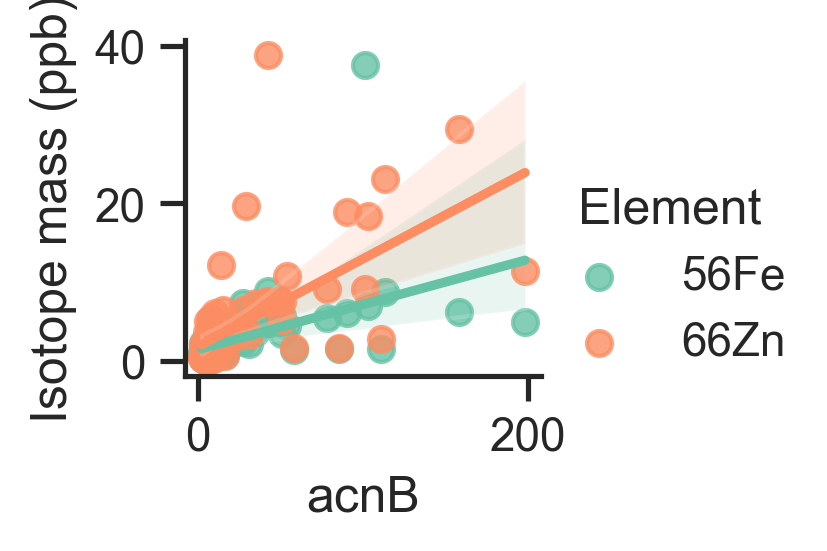

In [107]:
gene = "acnB"
elements = ["56Fe","66Zn"]

subset = prot_df.select(["x", "y", gene]).filter(pl.col(gene) > 1)

subset = metal_join_df.select(["x", "y",] + elements).join(subset, on=["x", "y"], how="inner")


# divide 182W by 1000
if "182W" in subset.columns:
    subset = subset.with_columns(pl.col("182W") / 1000)

# # subtract minimum value from each metal column
for element in elements:
    subset = subset.with_columns(pl.col(element) - 0.95 * pl.col(element).min())

subset = subset.melt(id_vars=["x", "y", gene], variable_name="Element", value_name="Isotope mass (ppb)")

# # normalize gene by maximum, normalize isotope mass by maximum,
# subset = subset.with_columns(pl.col(gene) / pl.col(gene).max())

# for each element, normalize isotope mass by maximum. use group_by and join.
element_max = subset.group_by("Element").agg(pl.col("Isotope mass (ppb)").max().alias("Element max"))
subset = subset.join(element_max, on="Element", how="left").with_columns((pl.col("Isotope mass (ppb)") / pl.col("Element max")).alias("Isotope mass (normalized)")).drop("Element max")

g = sns.lmplot(x=gene, y="Isotope mass (ppb)", hue="Element", data=subset, height = 2, aspect = 1.1,
                # col="Element", col_wrap=2, sharey=False
               )


# save as svg
plt.savefig("figures/acnB_zn_fe.svg", transparent=True)

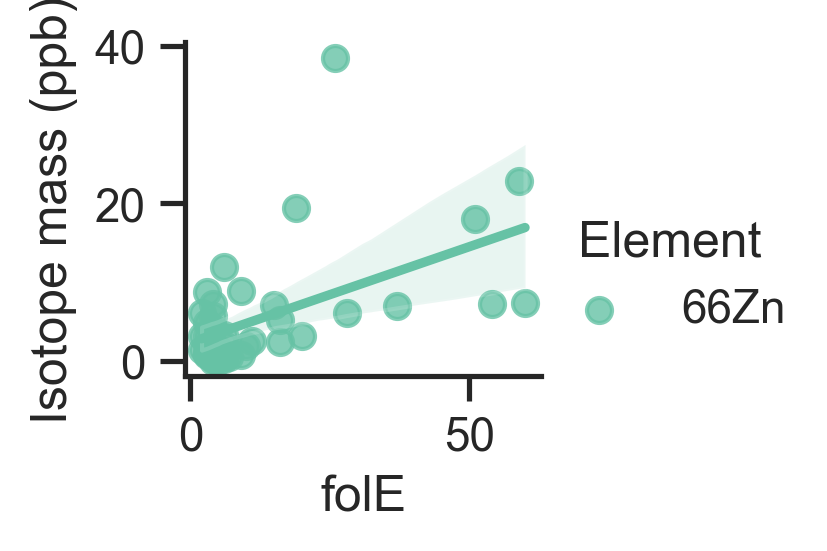

In [108]:
gene = "folE"
elements = ["66Zn"]

subset = prot_df.select(["x", "y", gene]).filter(pl.col(gene) > 1)

subset = metal_join_df.select(["x", "y",] + elements).join(subset, on=["x", "y"], how="inner")


# divide 182W by 1000
if "182W" in subset.columns:
    subset = subset.with_columns(pl.col("182W") / 1000)

# # subtract minimum value from each metal column
for element in elements:
    subset = subset.with_columns(pl.col(element) - 0.95 * pl.col(element).min())

subset = subset.melt(id_vars=["x", "y", gene], variable_name="Element", value_name="Isotope mass (ppb)")

# # normalize gene by maximum, normalize isotope mass by maximum,
# subset = subset.with_columns(pl.col(gene) / pl.col(gene).max())

# for each element, normalize isotope mass by maximum. use group_by and join.
element_max = subset.group_by("Element").agg(pl.col("Isotope mass (ppb)").max().alias("Element max"))
subset = subset.join(element_max, on="Element", how="left").with_columns((pl.col("Isotope mass (ppb)") / pl.col("Element max")).alias("Isotope mass (normalized)")).drop("Element max")

g = sns.lmplot(x=gene, y="Isotope mass (ppb)", hue="Element", data=subset, height = 2, aspect = 1.1,
                # col="Element", col_wrap=2, sharey=False
               )


# save as svg
plt.savefig("figures/acnB_zn_fe.svg", transparent=True)

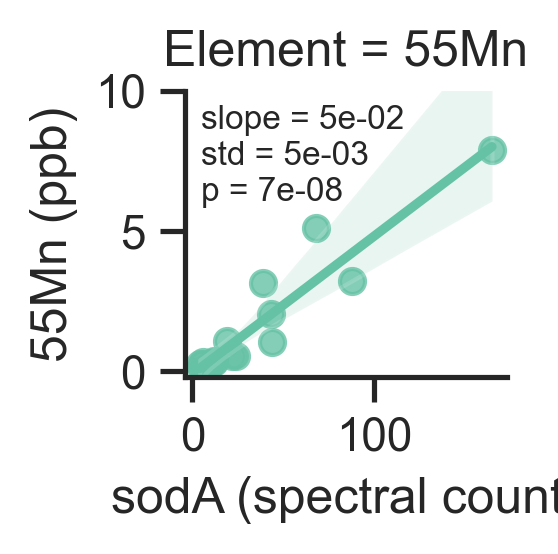

In [109]:
gene = "sodA"
elements = [ "55Mn"]

subset = prot_df.select(["x", "y", gene]).filter(pl.col(gene) > 1)

subset = metal_join_df.select(["x", "y",] + elements).join(subset, on=["x", "y"], how="inner")


# divide 182W by 1000
if "182W" in subset.columns:
    subset = subset.with_columns(pl.col("182W") / 1000)
    
# # subtract minimum value from each metal column
for element in elements:
    subset = subset.with_columns(pl.col(element) - 0.95 * pl.col(element).min())
    
subset = subset.melt(id_vars=["x", "y", gene], variable_name="Element", value_name="Isotope mass (ppb)")

# # normalize gene by maximum, normalize isotope mass by maximum, 
# subset = subset.with_columns(pl.col(gene) / pl.col(gene).max())

# for each element, normalize isotope mass by maximum. use group_by and join.
element_max = subset.group_by("Element").agg(pl.col("Isotope mass (ppb)").max().alias("Element max"))
subset = subset.join(element_max, on="Element", how="left").with_columns((pl.col("Isotope mass (ppb)") / pl.col("Element max")).alias("Isotope mass (normalized)")).drop("Element max")

g = sns.lmplot(x=gene, y="Isotope mass (ppb)", hue="Element", data=subset, height = 2, aspect = 0.8,
                col="Element", col_wrap=2, sharey=False
               )
# 
def annotate_slope_std(data, **kws):
    x = data[gene]
    y = data["Isotope mass (ppb)"]
    slope, intercept = np.polyfit(x, y, 1)
    resid_std = np.std(y - (slope * x + intercept))
    # calculate std dev of slope
    slope_std = resid_std / np.sqrt(np.sum((x - np.mean(x))**2))
    intercept_std = resid_std * np.sqrt(1/len(x) + np.mean(x)**2 / np.sum((x - np.mean(x))**2))

    pval = stats.t.sf(np.abs(slope / slope_std), df=len(x)-2) * 2  # two-tailed p-value


    ax = plt.gca()
    ax.text(0.05, 0.95, f"slope = {slope:.0e}\nstd = {slope_std:.0e}\np = {pval:.0e}"
            , transform=ax.transAxes, fontsize=8,va="top")

g.map_dataframe(annotate_slope_std)


# for ax in g.axes.flat:
#     ax.set_aspect('equal', adjustable='datalim')
# 
# plt.axis('equal')

# Make sure both axes include 0
g.set(ylim=(-0.2, 10))

# change axis title to sodA spectral count
g.set_axis_labels(f"{gene} (spectral count)", "55Mn (ppb)")

# save as svg
plt.savefig("figures/sodA_mn.svg", transparent=True)

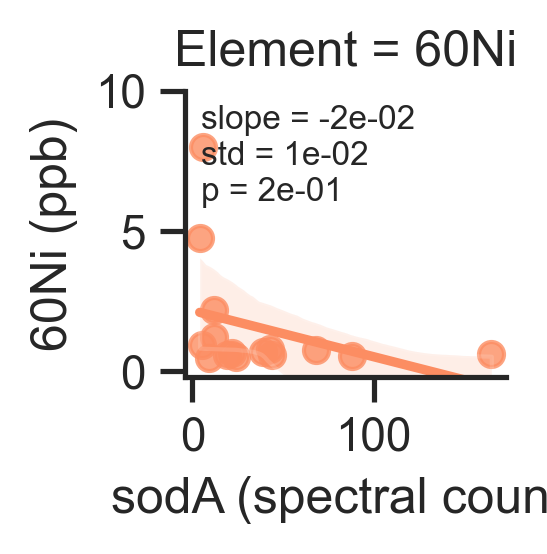

In [110]:
gene = "sodA"
elements = [ "60Ni"]

subset = prot_df.select(["x", "y", gene]).filter(pl.col(gene) > 1)

subset = metal_join_df.select(["x", "y",] + elements).join(subset, on=["x", "y"], how="inner")


# divide 182W by 1000
if "182W" in subset.columns:
    subset = subset.with_columns(pl.col("182W") / 1000)
    
# # # subtract minimum value from each metal column
# for element in elements:
#     subset = subset.with_columns(pl.col(element) - 0.95 * pl.col(element).min())
    
subset = subset.melt(id_vars=["x", "y", gene], variable_name="Element", value_name="Isotope mass (ppb)")

# # normalize gene by maximum, normalize isotope mass by maximum, 
# subset = subset.with_columns(pl.col(gene) / pl.col(gene).max())

# for each element, normalize isotope mass by maximum. use group_by and join.
element_max = subset.group_by("Element").agg(pl.col("Isotope mass (ppb)").max().alias("Element max"))
subset = subset.join(element_max, on="Element", how="left").with_columns((pl.col("Isotope mass (ppb)") / pl.col("Element max")).alias("Isotope mass (normalized)")).drop("Element max")

# get second color of set2 for palette
palette = [sns.color_palette("Set2")[1]]

g = sns.lmplot(x=gene, y="Isotope mass (ppb)", hue="Element", data=subset, height = 2, aspect = 0.8,
                col="Element", col_wrap=2, sharey=False, palette=palette
               )
# 
def annotate_slope_std(data, **kws):
    x = data[gene]
    y = data["Isotope mass (ppb)"]
    slope, intercept = np.polyfit(x, y, 1)
    resid_std = np.std(y - (slope * x + intercept))
    # calculate std dev of slope
    slope_std = resid_std / np.sqrt(np.sum((x - np.mean(x))**2))
    intercept_std = resid_std * np.sqrt(1/len(x) + np.mean(x)**2 / np.sum((x - np.mean(x))**2))

    pval = stats.t.sf(np.abs(slope / slope_std), df=len(x)-2) * 2  # two-tailed p-value


    ax = plt.gca()
    ax.text(0.05, 0.95, f"slope = {slope:.0e}\nstd = {slope_std:.0e}\np = {pval:.0e}"
            , transform=ax.transAxes, fontsize=8,va="top")

g.map_dataframe(annotate_slope_std)


# for ax in g.axes.flat:
#     ax.set_aspect('equal', adjustable='datalim')
# 
# plt.axis('equal')

# Make sure both axes include 0
g.set(ylim=(-0.2, 10))

# change axis title to sodA spectral count
g.set_axis_labels(f"{gene} (spectral count)", "60Ni (ppb)")

# save as svg
plt.savefig("figures/sodA_ni.svg", transparent=True)

# 2D schematic for plot

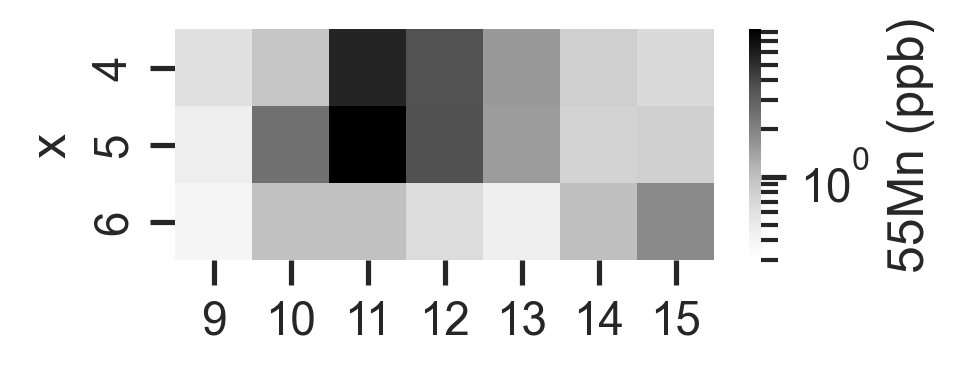

In [111]:
elements = ["55Mn", "60Ni", "56Fe","66Zn"]

subset = prot_df.select(["x", "y", gene]).filter(pl.col(gene) > 1)

subset = metal_join_df.select(["x", "y",] + elements).join(subset, on=["x", "y"], how="inner")

plt.figure(figsize=(3, 1))

# get unique values of y
unique_y = subset["y"].unique().to_list()
unique_x = subset["x"].unique().to_list()

# generate x and y lists for heatmap
x_ticks = sorted([str(i) for i in unique_x])
y_ticks = sorted([str(i) for i in unique_y])

# select new subset with is_in instead
subset = prot_df.select(["x", "y", gene]).filter(pl.col("x").is_in(unique_x) & pl.col("y").is_in(unique_y))

subset = metal_join_df.select(["x", "y",] + elements).join(subset, on=["x", "y"], how="inner")

sns.heatmap(subset.pivot(values="55Mn", index="x", on="y", ).sort(by="x", descending=False).select(["x"] + [str(i) for i in unique_y]).to_pandas().set_index("x"), square=True, norm=LogNorm(vmin=0.3), cmap="Greys", cbar_kws={'label': '55Mn (ppb)'}, # xticklabels=False, yticklabels=False
            )

# save as svg
plt.savefig("figures/sodA_mn_heatmap.svg", transparent=True)

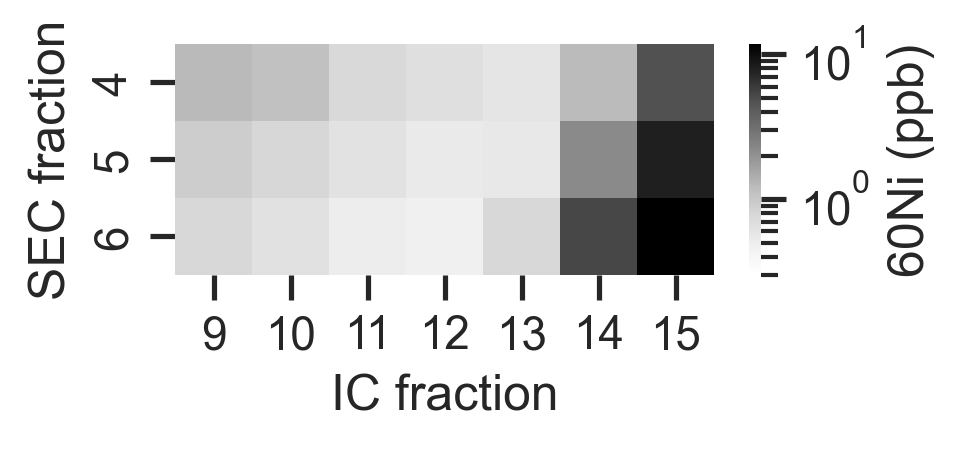

In [112]:
plt.figure(figsize=(3, 1))

sns.heatmap(subset.pivot(values="60Ni", index="x", on="y", ).sort(by="x", descending=False).select(["x"] + [str(i) for i in unique_y]).to_pandas().set_index("x"), square=True, norm=LogNorm(vmin=0.3), cmap="Greys", cbar_kws={'label': '60Ni (ppb)'}, # xticklabels=False, yticklabels=False
            )


# set xaxis and yaxis labels
plt.xlabel("IC fraction")
plt.ylabel("SEC fraction")

# save as svg
plt.savefig("figures/sodA_ni_heatmap.svg", transparent=True)


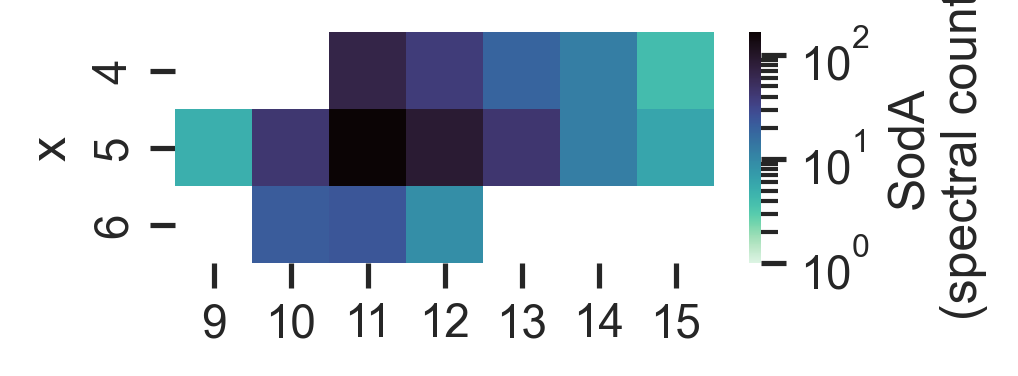

In [113]:
plt.figure(figsize=(3, 1))

plot_vals = subset.pivot(values="sodA", index="x", on="y", ).sort(by="x", descending=False).select([str(i) for i in unique_y]).to_numpy()[:, 1:]

# fill with 0 
plot_vals = np.nan_to_num(plot_vals, nan=0)

sns.heatmap(subset.pivot(values="sodA", index="x", on="y", ).sort(by="x", descending=False).select(["x"] + [str(i) for i in unique_y]).to_pandas().set_index("x"), square=True, norm=LogNorm(vmin=1), cmap="mako_r", cbar_kws={'label': 'SodA\n(spectral count)'}, # xticklabels=False, yticklabels=False
            )

# save as svg
plt.savefig("figures/sodA_heatmap.svg", transparent=True)

# Schematic for plotting

In [114]:
subset

x,y,55Mn,60Ni,56Fe,66Zn,sodA
i64,i64,f64,f64,f64,f64,i64
4,9,0.605971,1.232198,1.343217,0.707655,0
4,10,0.907338,1.123747,1.368064,0.666845,0
4,11,5.555798,0.754913,1.689285,0.428284,68
4,12,3.588784,0.675728,1.631752,0.374045,39
4,13,1.522298,0.592733,1.516023,0.394618,19
…,…,…,…,…,…,…
6,11,0.981025,0.503377,3.45543,1.429034,24
6,12,0.647693,0.481518,2.217692,1.76077,9
6,13,0.474455,0.770985,1.645717,2.47371,0


In [115]:
x_lims_example = [5, 13]
y_lims_example = [9, 15]

n_x_samples = x_lims_example[1] - x_lims_example[0]
n_y_samples = y_lims_example[1] - y_lims_example[0]

x_labels = np.arange(x_lims_example[0], x_lims_example[1]+1)
y_labels = np.arange(y_lims_example[0], y_lims_example[1]+1)

x_highlight = 5

metal_example_df = metal_join_df.filter((pl.col("x") <= x_lims_example[1]) & (pl.col("x") >= x_lims_example[0]) & (pl.col("y") <= y_lims_example[1]) & (pl.col("y") >= y_lims_example[0]))

In [116]:
prot_example_1d_df = prot_df.filter((pl.col("x") == x_highlight) & (pl.col("y") <= y_lims_example[1]) & (pl.col("y") >= y_lims_example[0]))

# pick metE, folE, can
prot_example_1d_df = prot_example_1d_df.select(["x", "y", "sodA"])

# melt
prot_example_1d_df = prot_example_1d_df.melt(variable_name="Gene", value_name="Spectral count", id_vars=["x", "y"])

# divide each protein by it's sum
prot_example_1d_sum_df = prot_example_1d_df.group_by(["Gene"]).agg(pl.sum("Spectral count").alias("Contribution_sum"))

# join 
prot_example_1d_df = prot_example_1d_df.join(prot_example_1d_sum_df, on=["Gene"])

# divide by the sum and rename to Normalized contribution
prot_example_1d_df = prot_example_1d_df.with_columns((pl.col("Spectral count") / pl.col("Contribution_sum")).alias("Normalized contribution")).drop("Contribution_sum")

# rename Gene to Protein
prot_example_1d_df = prot_example_1d_df.rename({"Gene": "Protein"})

prot_example_1d_df

x,y,Protein,Spectral count,Normalized contribution
i64,i64,str,i64,f64
5,9,"""sodA""",5,0.013774
5,10,"""sodA""",43,0.118457
5,11,"""sodA""",165,0.454545
5,12,"""sodA""",88,0.242424
5,13,"""sodA""",44,0.121212
5,14,"""sodA""",12,0.033058
5,15,"""sodA""",6,0.016529


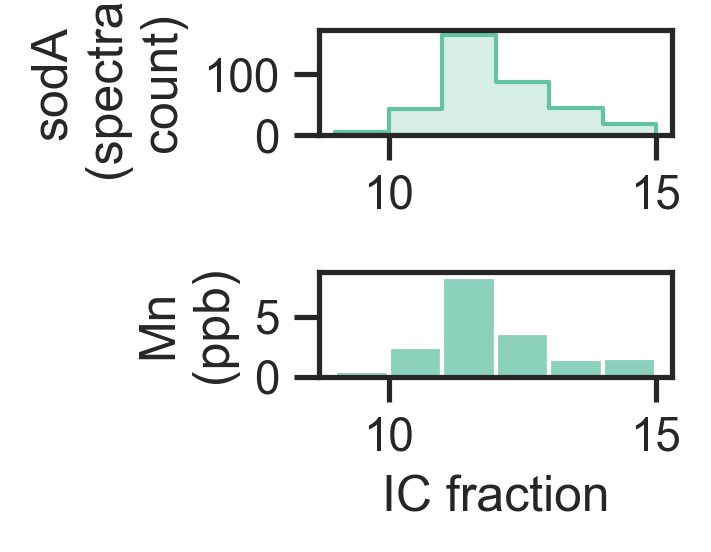

In [117]:
# plot 1d histogram of the metal along x=9 
metal_example_1d_df = metal_example_df.filter(pl.col("x") == x_highlight)


f, ax = plt.subplots(2, 1, figsize=(2.5, 2.))

g = sns.histplot(data=metal_example_1d_df, x="y", weights="55Mn", bins=n_y_samples, ax=ax[1])

# change ylabel
g.set_ylabel(f"{metal}\n(ppb)")

# change xlabel
g.set_xlabel("IC fraction")
g.set_ylabel("Mn\n(ppb)")

# do same for proteins
g = sns.histplot(data=prot_example_1d_df, x="y", weights="Spectral count", 
                 bins=n_y_samples, binrange=y_lims_example, ax=ax[0], hue="Protein", fill=True, element="step", legend=False)

# change labels
g.set_ylabel("sodA\n(spectral\ncount)")

# drop xlabel for g
g.set_xlabel("")

f.tight_layout()

# save as svg
f.savefig("figures/scatter_example.svg", transparent=True)

# Multiply protein totals by slopes to get relative metal fractions.

In [118]:
zn_genes = ["metE", "fbaA", "folE", "rpoC", "can", "pyrI", "pyrC",] #

zn_reg = regression_results.filter((pl.col("Gene").is_in(zn_genes)) & (pl.col("Element") == "66Zn")).select(["Gene", "slope", "slope_std_err"])

# join with sums of those genes
gene_sums = prot_df.select(pl.col(zn_genes)).sum().melt(variable_name="Gene", value_name="Total count")
zn_reg = zn_reg.join(gene_sums, on="Gene", how="left").with_columns((pl.col("slope") * pl.col("Total count")).alias("Relative fraction"))


# add column with element
zn_reg = zn_reg.with_columns(pl.lit("66Zn").alias("Element"))

# add std error of relative Zn fraction by multiplying slope_std_err by total count
zn_reg = zn_reg.with_columns((pl.col("slope_std_err") * pl.col("Total count")).alias("Relative fraction std error"))


# divide relative fraction and std error by max relative fraction
max_relative_fraction = zn_reg.select(pl.col("Relative fraction")).max()[0, 0]
zn_reg = zn_reg.with_columns((pl.col("Relative fraction") / max_relative_fraction).alias("Relative fraction"))
zn_reg = zn_reg.with_columns((pl.col("Relative fraction std error") / max_relative_fraction).alias("Relative fraction std error"))

# drop other cols
zn_reg = zn_reg.select(["Gene", "Element", "Relative fraction", "Relative fraction std error"])

zn_reg

Gene,Element,Relative fraction,Relative fraction std error
str,str,f64,f64
"""pyrI""","""66Zn""",0.453005,0.159845
"""can""","""66Zn""",0.205654,0.17484
"""rpoC""","""66Zn""",0.149316,0.123325
"""metE""","""66Zn""",1.0,0.108209
"""pyrC""","""66Zn""",0.23121,0.232841
"""folE""","""66Zn""",0.541333,0.136535
"""fbaA""","""66Zn""",0.548853,0.110556


In [119]:
mn_genes = ["sodA", "speB",]

mn_reg = regression_results.filter((pl.col("Gene").is_in(mn_genes)) & (pl.col("Element") == "55Mn")).select(["Gene", "slope", "slope_std_err"])

# join with sums of those genes
gene_sums = prot_df.select(pl.col(mn_genes)).sum().melt(variable_name="Gene", value_name="Total count")
mn_reg = mn_reg.join(gene_sums, on="Gene", how="left").with_columns((pl.col("slope") * pl.col("Total count")).alias("Relative fraction"))

# add column with element
mn_reg = mn_reg.with_columns(pl.lit("55Mn").alias("Element"))

# add std error of relative Zn fraction by multiplying slope_std_err by total count
mn_reg = mn_reg.with_columns((pl.col("slope_std_err") * pl.col("Total count")).alias("Relative fraction std error"))

max_relative_fraction = mn_reg.select(pl.col("Relative fraction")).max()[0, 0]
mn_reg = mn_reg.with_columns((pl.col("Relative fraction") / max_relative_fraction).alias("Relative fraction"))
mn_reg = mn_reg.with_columns((pl.col("Relative fraction std error") / max_relative_fraction).alias("Relative fraction std error"))

mn_reg = mn_reg.select(["Gene", "Element", "Relative fraction", "Relative fraction std error"])

mn_reg

Gene,Element,Relative fraction,Relative fraction std error
str,str,f64,f64
"""sodA""","""55Mn""",1.0,0.099233
"""speB""","""55Mn""",0.071223,0.023698


In [120]:
# combine mn_reg and zn_reg
combined_reg = pl.concat([zn_reg, mn_reg, 
                          # fe_reg
                          ])

# add source to be "experiment"
combined_reg = combined_reg.with_columns(pl.lit("Observed metal\nabundance").alias("Source"))

combined_reg

Gene,Element,Relative fraction,Relative fraction std error,Source
str,str,f64,f64,str
"""pyrI""","""66Zn""",0.453005,0.159845,"""Observed metal abundance"""
"""can""","""66Zn""",0.205654,0.17484,"""Observed metal abundance"""
"""rpoC""","""66Zn""",0.149316,0.123325,"""Observed metal abundance"""
"""metE""","""66Zn""",1.0,0.108209,"""Observed metal abundance"""
"""pyrC""","""66Zn""",0.23121,0.232841,"""Observed metal abundance"""
"""folE""","""66Zn""",0.541333,0.136535,"""Observed metal abundance"""
"""fbaA""","""66Zn""",0.548853,0.110556,"""Observed metal abundance"""
"""sodA""","""55Mn""",1.0,0.099233,"""Observed metal abundance"""
"""speB""","""55Mn""",0.071223,0.023698,"""Observed metal abundance"""


In [121]:

name_df = pl.read_csv("external_data/ecocyc_name_conversion.txt", separator="\t")
# drop non unique rows for Common-Name
name_df = name_df.unique(subset=["Common-Name"])

li = pl.read_csv("external_data/Li_2014_profiling.csv")
li_df = li.join(name_df, left_on="Gene", right_on="Common-Name")
li_df

Gene,MOPS complete,MOPS minimal,MOPS complete without methionine,Proteins,Genes,Accession-1 of Gene
str,i64,i64,i64,str,str,str
"""yggT""",1551,383,702,"""G7528-MONOMER""","""G7528""","""b2952"""
"""scpA""",0,1,0,"""METHYLMALONYL-COA-MUT-MONOMER""","""EG11444""","""b2917"""
"""yqjE""",443,691,314,"""G7613-MONOMER""","""G7613""","""b3099"""
"""rsmC""",2214,401,901,"""G7950-MONOMER""","""G7950""","""b4371"""
"""ydbJ""",1254,1385,1527,"""MONOMER0-2672""","""G0-10450""","""b4529"""
…,…,…,…,…,…,…
"""ycgR""",3,9,0,"""G6623-MONOMER""","""G6623""","""b1194"""
"""mdh""",9529,16149,7048,"""MALATE-DEHASE-MONOMER""","""EG10576""","""b3236"""
"""ybaV""",41,23,44,"""G6243-MONOMER""","""G6243""","""b0442"""


In [122]:
# create approximate model data set
cols = ["Gene", "Element","Stoichiometry"]
data = [["metE", "66Zn", 1],
        ["fbaA", "66Zn", 2],
        ["rpoC", "66Zn", 2],
        ["folE", "66Zn",1],
        ["can", "66Zn", 1],
        ["pyrI", "66Zn", 1],
        ["pyrC", "66Zn",2],
        ["sodA", "55Mn",1],
        ["speB", "55Mn",2],
        ]

# create dataframe
model_df = pl.DataFrame(np.array(data), schema=cols)

# Cast stoichiometry to float
model_df = model_df.with_columns(pl.col("Stoichiometry").cast(pl.Float64))

# join with li on gene
model_df_full = model_df.join(li_df.select(["Gene", "MOPS minimal"]), on="Gene", how="left")

# normalize each MOPS complete value by the maximum for that element
model_df = model_df_full.with_columns((pl.col("MOPS minimal")  * pl.col("Stoichiometry")).alias("Relative fraction")).drop("MOPS minimal", "Stoichiometry")
model_df_full = model_df_full.with_columns((pl.col("MOPS minimal")  * pl.col("Stoichiometry")).alias("Relative fraction"))

# normalize relative fraction by max for each element
max_relative_fraction = model_df.group_by("Element").agg(pl.col("Relative fraction").max().alias("Max relative fraction"))
model_df = model_df.join(max_relative_fraction, on="Element", how="left").with_columns((pl.col("Relative fraction") / pl.col("Max relative fraction")).alias("Relative fraction")).drop("Max relative fraction")

# add std error as 20% of relative fraction
model_df = model_df.with_columns((pl.col("Relative fraction") * 0.0).alias("Relative fraction std error"))



In [123]:


# convert Relative fraction and std error to float
model_df = model_df.with_columns(pl.col("Relative fraction").cast(pl.Float64))
model_df = model_df.with_columns(pl.col("Relative fraction std error").cast(pl.Float64))

# add source column with value "Model"
model_df = model_df.with_columns(pl.lit("Predicted metal abundance\n(assuming 100% metalation)").alias("Source"))

# concat with combined_reg
model_exp_fraction_df = pl.concat([combined_reg, model_df])

print(model_exp_fraction_df)

shape: (18, 5)
┌──────┬─────────┬───────────────────┬─────────────────────────────┬───────────────────────────┐
│ Gene ┆ Element ┆ Relative fraction ┆ Relative fraction std error ┆ Source                    │
│ ---  ┆ ---     ┆ ---               ┆ ---                         ┆ ---                       │
│ str  ┆ str     ┆ f64               ┆ f64                         ┆ str                       │
╞══════╪═════════╪═══════════════════╪═════════════════════════════╪═══════════════════════════╡
│ pyrI ┆ 66Zn    ┆ 0.453005          ┆ 0.159845                    ┆ Observed metal            │
│      ┆         ┆                   ┆                             ┆ abundance                 │
│ can  ┆ 66Zn    ┆ 0.205654          ┆ 0.17484                     ┆ Observed metal            │
│      ┆         ┆                   ┆                             ┆ abundance                 │
│ rpoC ┆ 66Zn    ┆ 0.149316          ┆ 0.123325                    ┆ Observed metal            │
│      ┆       

In [124]:
# since error bars are being silly, just sample 1000 values from a normal distribution with mean as relative fraction and std as relative fraction std error, and plot those as a plot with sd

sampled_data = []

for row in model_exp_fraction_df.iter_rows():
    samples = np.random.normal(loc=row[2], scale=row[3], size=10000)
    samples_as_rows = [[row[0], row[1], sample, row[4]] for sample in samples]
    
    sampled_data.extend(samples_as_rows)
    
sample_df = pl.DataFrame(np.array(sampled_data), schema=["Gene", "Element", "Relative fraction", "Source"])

# convert Relative fraction to float
sample_df = sample_df.with_columns(pl.col("Relative fraction").cast(pl.Float64))

gene_order = ["metE", "fbaA", "pyrI", "pyrC", "rpoC", "can",]

# create catplot
# sns.catplot(x="Gene", y="Relative fraction", col="Element", hue="Source", data=sample_df.filter(pl.col("Element") == "66Zn").to_pandas(), dodge=0.3, join=False, legend=True, kind="point", height=3, aspect=1.5, errorbar="sd", sharex=False, capsize=0.2, order=gene_order)

In [125]:
# sns.catplot(x="Gene", y="Relative fraction", col="Element", hue="Source", data=sample_df.filter(pl.col("Element") == "55Mn").to_pandas(), dodge=0.3, join=False, legend=False, kind="point", height=3, aspect=0.7, errorbar="sd", sharex=False, capsize=0.2, )

Slope: 1.059 ± 0.125 (p-value: 6.526e-01)


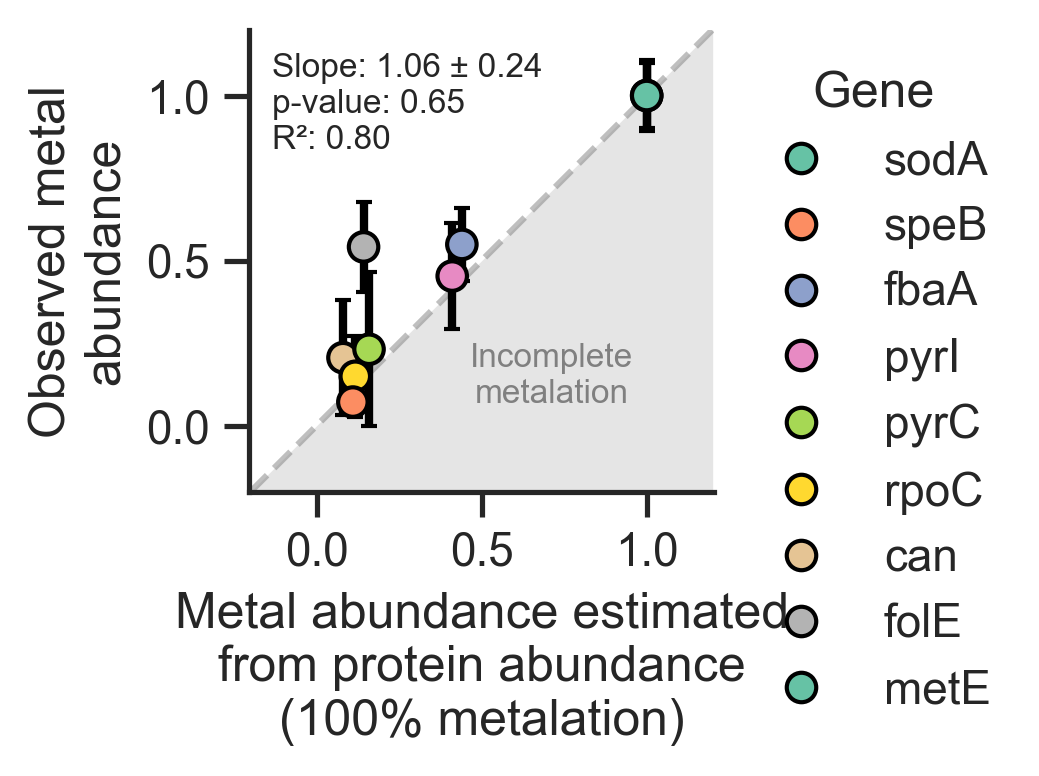

In [127]:
# do a scatterplot of pivoted model_exp_fraction_df with different sources as x and y

plt.figure(figsize=(2.,2.))

hue_order = ["sodA", "speB", "fbaA", "pyrI", "pyrC", "rpoC", "can", "folE", "metE"]

pivoted = model_exp_fraction_df.pivot(values="Relative fraction", index="Gene", on="Source")
pivoted_error = model_exp_fraction_df.pivot(values="Relative fraction std error", index="Gene", on="Source")
g = sns.scatterplot(x=pivoted["Predicted metal abundance\n(assuming 100% metalation)"], 
                y=pivoted["Observed metal\nabundance"],s=50,edgecolor='black', linewidth=1, 
                    hue=pivoted["Gene"], palette="Set2", hue_order=hue_order)

x = pivoted["Predicted metal abundance\n(assuming 100% metalation)"].to_numpy()
y = pivoted["Observed metal\nabundance"].to_numpy()

# instead fit with intercept = 0
x_n = x[:,np.newaxis]
a, _, _, _ = np.linalg.lstsq(x_n, y)
slope = a[0]

# slope, intercept = np.polyfit(x, y, 1)
resid_std = np.std(y - (slope * x))
# calculate std dev of slope
slope_std = resid_std / np.sqrt(np.sum((x - np.mean(x))**2))
slope_pval = stats.t.sf(np.abs((slope-1) / slope_std), df=len(x)-2) * 2  # two-tailed p-value

# calculate R^2
y_pred = slope * x
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)

print( f"Slope: {slope:.3f} ± {slope_std:.3f} (p-value: {slope_pval:.3e})")

# add error bars
for i in range(pivoted.shape[0]):
    plt.errorbar(x=pivoted["Predicted metal abundance\n(assuming 100% metalation)"][i],
                 y=pivoted["Observed metal\nabundance"][i],
                 xerr=pivoted_error["Predicted metal abundance\n(assuming 100% metalation)"][i],
                 yerr=pivoted_error["Observed metal\nabundance"][i],
                 fmt='none', ecolor='k', alpha=1, capsize=2, capthick=1, elinewidth=2,zorder=0)




# equal axis aspect
plt.gca().set_aspect('equal', adjustable='datalim')

# set y and x lim
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)

sns.despine()

# add dashed line y=x
plt.plot([-0.2, 1.2], [-0.2, 1.2], ls="--", c="grey", alpha=0.5, zorder=-1)

# calculate CI for slope
ci = 1.96 * slope_std

# add text with p value and CI
plt.text(0.05, 0.95, f"Slope: {slope:.2f} ± {ci:.2f}\np-value: {slope_pval:.2f}\nR²: {r_squared:.2f}", 
         transform=plt.gca().transAxes, fontsize=8, va="top")

# create a grey triangle for the lower part of the plot below x=y
plt.fill_between([-0.2, 1.2], [-0.2, 1.2], -0.2, color='grey', alpha=0.2, zorder=-2, linewidth=0)

# add gray text in the triangle that says "Under-metalated\n(less metal than expected)"
plt.text(0.65, 0.25, "Incomplete\nmetalation", transform=plt.gca().transAxes, fontsize=8, ha="center", va="center", color="grey", alpha=1)

# set legend out
sns.move_legend(g, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)

# change x label
plt.xlabel("Metal abundance estimated\nfrom protein abundance\n(100% metalation)")

# save as svg
plt.savefig("figures/incomplete_met_model_exp_scatter.svg", transparent=True)

# schematic of mismetallation

In [128]:
subset

x,y,55Mn,60Ni,56Fe,66Zn,sodA
i64,i64,f64,f64,f64,f64,i64
4,9,0.605971,1.232198,1.343217,0.707655,0
4,10,0.907338,1.123747,1.368064,0.666845,0
4,11,5.555798,0.754913,1.689285,0.428284,68
4,12,3.588784,0.675728,1.631752,0.374045,39
4,13,1.522298,0.592733,1.516023,0.394618,19
…,…,…,…,…,…,…
6,11,0.981025,0.503377,3.45543,1.429034,24
6,12,0.647693,0.481518,2.217692,1.76077,9
6,13,0.474455,0.770985,1.645717,2.47371,0


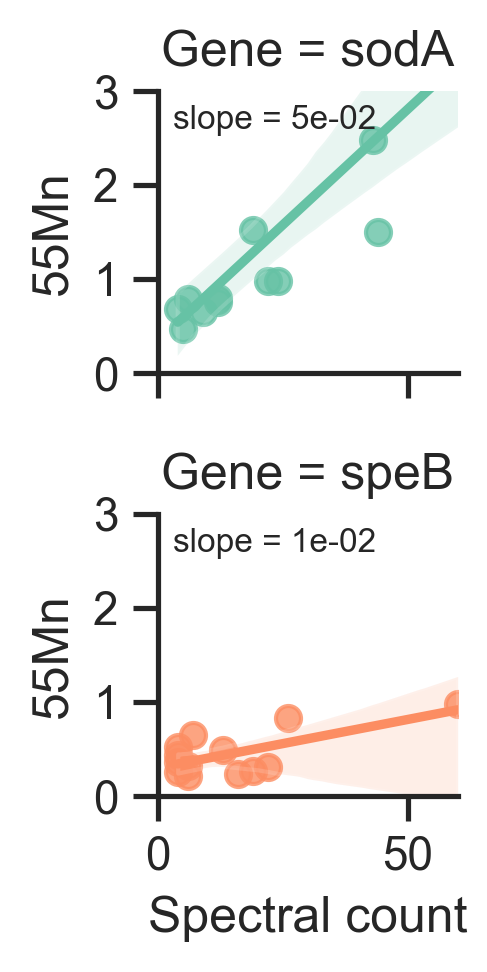

In [129]:
subset1 = prot_df.select(["x", "y", "sodA"]).filter(pl.col("sodA") > 1)
subset2 = prot_df.select(["x", "y", "speB"]).filter(pl.col("speB") > 1)

# concat
subset = pl.concat([subset1, subset2], how="diagonal_relaxed")

# melt and drop null for genes
subset = subset.melt(id_vars=["x", "y"], variable_name="Gene", value_name="Spectral count").filter(pl.col("Spectral count") > 1)

subset = metal_join_df.select(["x", "y",] + elements).join(subset, on=["x", "y"], how="inner")
subset
g = sns.lmplot(x="Spectral count", y="55Mn", hue="Gene", data=subset, height = 1.7, aspect =1.1, row="Gene"
               )

def annotate_slope_std(data, **kws):
    x = data["Spectral count"]
    y = data["55Mn"]
    slope, intercept = np.polyfit(x, y, 1)
    resid_std = np.std(y - (slope * x + intercept))
    # calculate std dev of slope
    slope_std = resid_std / np.sqrt(np.sum((x - np.mean(x))**2))
    intercept_std = resid_std * np.sqrt(1/len(x) + np.mean(x)**2 / np.sum((x - np.mean(x))**2))

    pval = stats.t.sf(np.abs(slope / slope_std), df=len(x)-2) * 2  # two-tailed p-value


    ax = plt.gca()
    ax.text(0.05, 0.95, f"slope = {slope:.0e}"
            , transform=ax.transAxes, fontsize=8,va="top")

g.map_dataframe(annotate_slope_std)

# annotate with slope = 0.05 and slope = 0.01 
# plt.text(0.95, 0.95, f"Slope = 0.05", transform=g.axes[0][0].transAxes, fontsize=8, va="top")
# plt.text(0.95, 0.3, f"Slope = 0.01", transform=g.axes[0][0].transAxes, fontsize=8, va="top")

# set xlim to 60 and ylim to 3
g.set(xlim=(0, 60))
g.set(ylim=(0, 3))

# set legend at top
# g._legend.set_bbox_to_anchor((0.5, 1.05))

# save as svg
plt.savefig("figures/mn_slopes.svg", transparent=True)

In [130]:
mn_reg = regression_results.filter((pl.col("Gene").is_in(mn_genes)) & (pl.col("Element") == "55Mn")).select(["Gene", "slope", "slope_std_err"])

# join with sums of those genes
gene_sums = prot_df.select(pl.col(mn_genes)).sum().melt(variable_name="Gene", value_name="Total spectral count")
mn_reg = mn_reg.join(gene_sums, on="Gene", how="left").with_columns((pl.col("slope") * pl.col("Total spectral count")).alias("Total metal mass (ppb)"))

# add column with element
mn_reg = mn_reg.with_columns(pl.lit("55Mn").alias("Element"))

# add std error of relative Zn fraction by multiplying slope_std_err by total count
mn_reg = mn_reg.with_columns((pl.col("slope_std_err") * pl.col("Total spectral count")).alias("Relative fraction std error"))

mn_reg = mn_reg.join(model_df, on="Gene")

# normalize Total metal mass and Relative fraction by max Total metal mass
max_total_metal_mass = mn_reg.select(pl.col("Total metal mass (ppb)")).max()[0, 0]
mn_reg = mn_reg.with_columns((pl.col("Total metal mass (ppb)") / max_total_metal_mass).alias("Total metal mass (normalized)"))
mn_reg = mn_reg.with_columns((pl.col("Relative fraction std error") / max_total_metal_mass).alias("Relative fraction std error (normalized)"))

mn_reg

Gene,slope,slope_std_err,Total spectral count,Total metal mass (ppb),Element,Relative fraction std error,Element_right,Relative fraction,Relative fraction std error_right,Source,Total metal mass (normalized),Relative fraction std error (normalized)
str,f64,f64,i64,f64,str,f64,str,f64,f64,str,f64,f64
"""sodA""",0.049172,0.004879,560,27.536286,"""55Mn""",2.732501,"""55Mn""",1.0,0.0,"""Predicted metal abundance (ass…",1.0,0.099233
"""speB""",0.010268,0.003417,191,1.961206,"""55Mn""",0.652554,"""55Mn""",0.109576,0.0,"""Predicted metal abundance (ass…",0.071223,0.023698


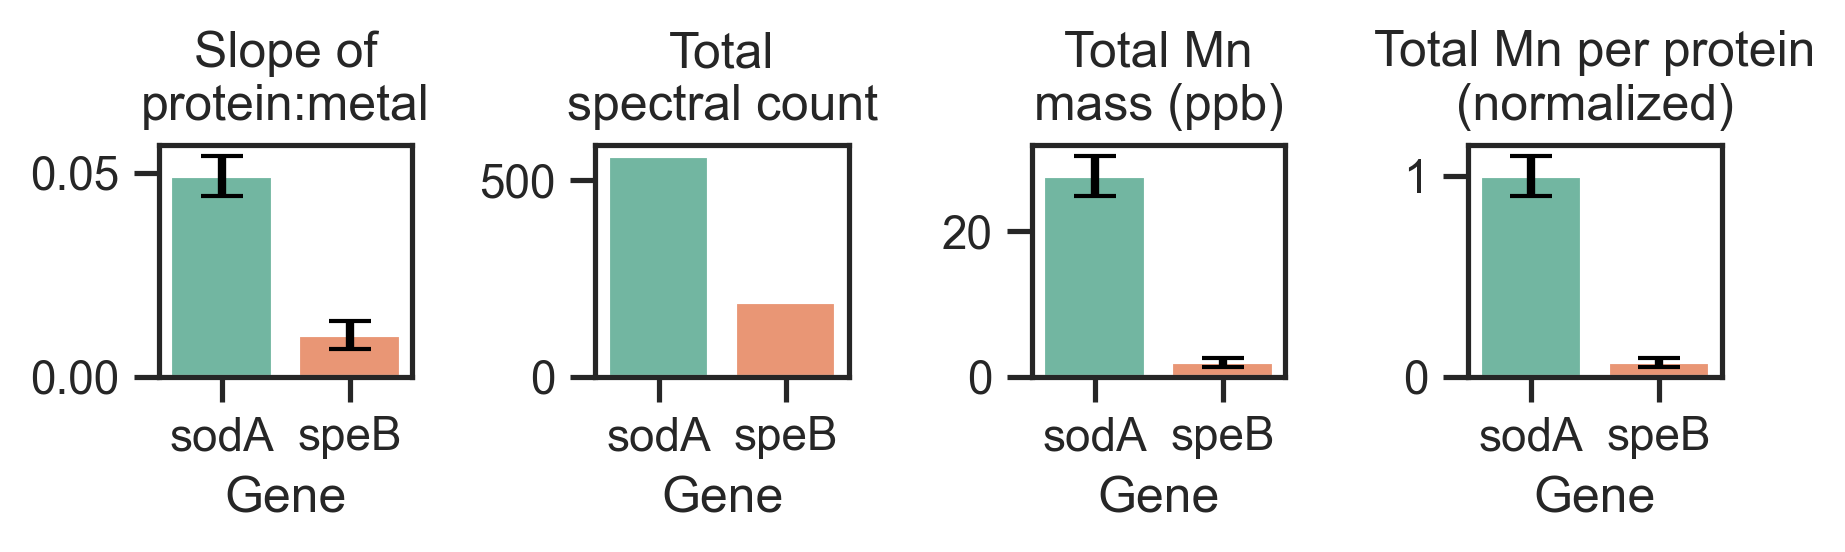

In [131]:
# create separate bar plots for slope, total spectral count, total metal mass and relative fraction
f, ax = plt.subplots(1, 4, figsize=(6, 2))

sns.barplot(x="Gene", y="slope", data=mn_reg.to_pandas(), ax=ax[0], hue="Gene")
ax[0].set_title("Slope of\nprotein:metal")
# add error bar
ax[0].errorbar(x=mn_reg["Gene"].to_numpy(), y=mn_reg["slope"].to_numpy(), yerr=mn_reg["slope_std_err"].to_numpy(), fmt='none', ecolor='k', alpha=1, capsize=5, capthick=1, elinewidth=2)
sns.barplot(x="Gene", y="Total spectral count", data=mn_reg.to_pandas(), ax=ax[1], hue="Gene")
ax[1].set_title("Total\nspectral count")
sns.barplot(x="Gene", y="Total metal mass (ppb)", data=mn_reg.to_pandas(), ax=ax[2], hue="Gene")
ax[2].set_title("Total Mn\nmass (ppb)")
# add error bars based on Relative fraction std error
ax[2].errorbar(x=mn_reg["Gene"].to_numpy(), y=mn_reg["Total metal mass (ppb)"].to_numpy(), yerr=mn_reg["Relative fraction std error"].to_numpy(), fmt='none', ecolor='k', alpha=1, capsize=5, capthick=1, elinewidth=2)

# plot normalized metal mass
sns.barplot(x="Gene", y="Total metal mass (normalized)", data=mn_reg.to_pandas(), ax=ax[3], hue="Gene")
ax[3].set_title("Total Mn per protein\n(normalized)")
ax[3].errorbar(x=mn_reg["Gene"].to_numpy(), y=mn_reg["Total metal mass (normalized)"].to_numpy(), yerr=mn_reg["Relative fraction std error (normalized)"].to_numpy(), fmt='none', ecolor='k', alpha=1, capsize=5, capthick=1, elinewidth=2)

# turn off all y axis labels
for a in ax:
    a.set_ylabel("")

f.tight_layout()

# save as svg
f.savefig("figures/mn_regression_bars.svg", transparent=True)

In [132]:
model_df_plot = model_df_full.filter(pl.col("Element") == "55Mn").rename({"MOPS minimal": "Protein copies per cell", "Relative fraction": "Total Mn bound (atoms/cell)"})

# create normalized version of Mn bound
max_mn_bound = model_df_plot.select(pl.col("Total Mn bound (atoms/cell)")).max()[0, 0]
model_df_plot = model_df_plot.with_columns((pl.col("Total Mn bound (atoms/cell)") / max_mn_bound).alias("Total Mn bound (normalized)"))

model_df_plot

Gene,Element,Stoichiometry,Protein copies per cell,Total Mn bound (atoms/cell),Total Mn bound (normalized)
str,str,f64,i64,f64,f64
"""sodA""","""55Mn""",1.0,20479,20479.0,1.0
"""speB""","""55Mn""",2.0,1122,2244.0,0.109576


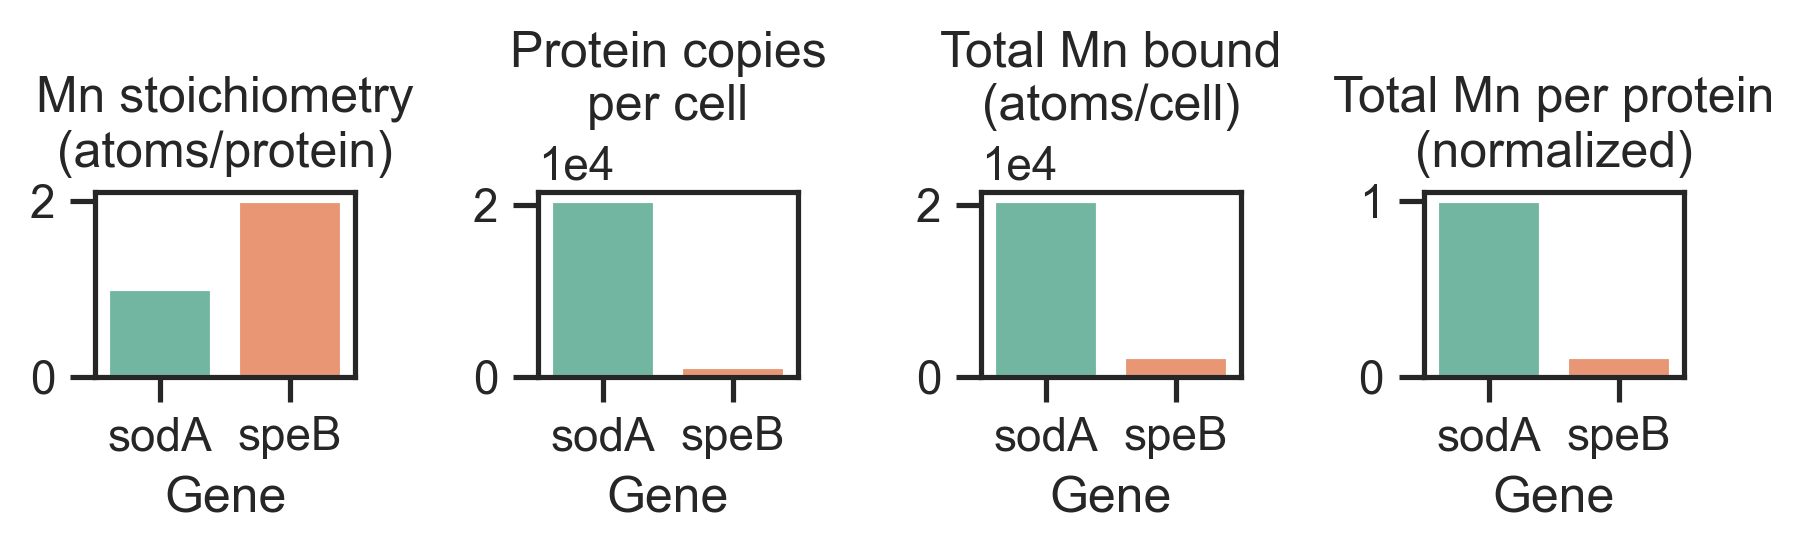

In [133]:
# create the same kind of barplot with the model data. First protein copies, then stoichiometry, then total Mn bound, then total Mn bound normalized
f, ax = plt.subplots(1, 4, figsize=(6, 2))
sns.barplot(x="Gene", y="Protein copies per cell", data=model_df_plot.to_pandas(), ax=ax[1], hue="Gene")
ax[1].set_title("Protein copies\nper cell")
sns.barplot(x="Gene", y="Stoichiometry", data=model_df_plot.to_pandas(), ax=ax[0], hue="Gene")
ax[0].set_title("Mn stoichiometry\n(atoms/protein)")
sns.barplot(x="Gene", y="Total Mn bound (atoms/cell)", data=model_df_plot.to_pandas(), ax=ax[2], hue="Gene")
ax[2].set_title("Total Mn bound\n(atoms/cell)")

sns.barplot(x="Gene", y="Total Mn bound (normalized)", data=model_df_plot.to_pandas(), ax=ax[3], hue="Gene")
ax[3].set_title("Total Mn per protein\n(normalized)")

# turn off all y axis labels
for a in ax:
    a.set_ylabel("")

f.tight_layout()

# save as svg
f.savefig("figures/mn_model_bars.svg", transparent=True)

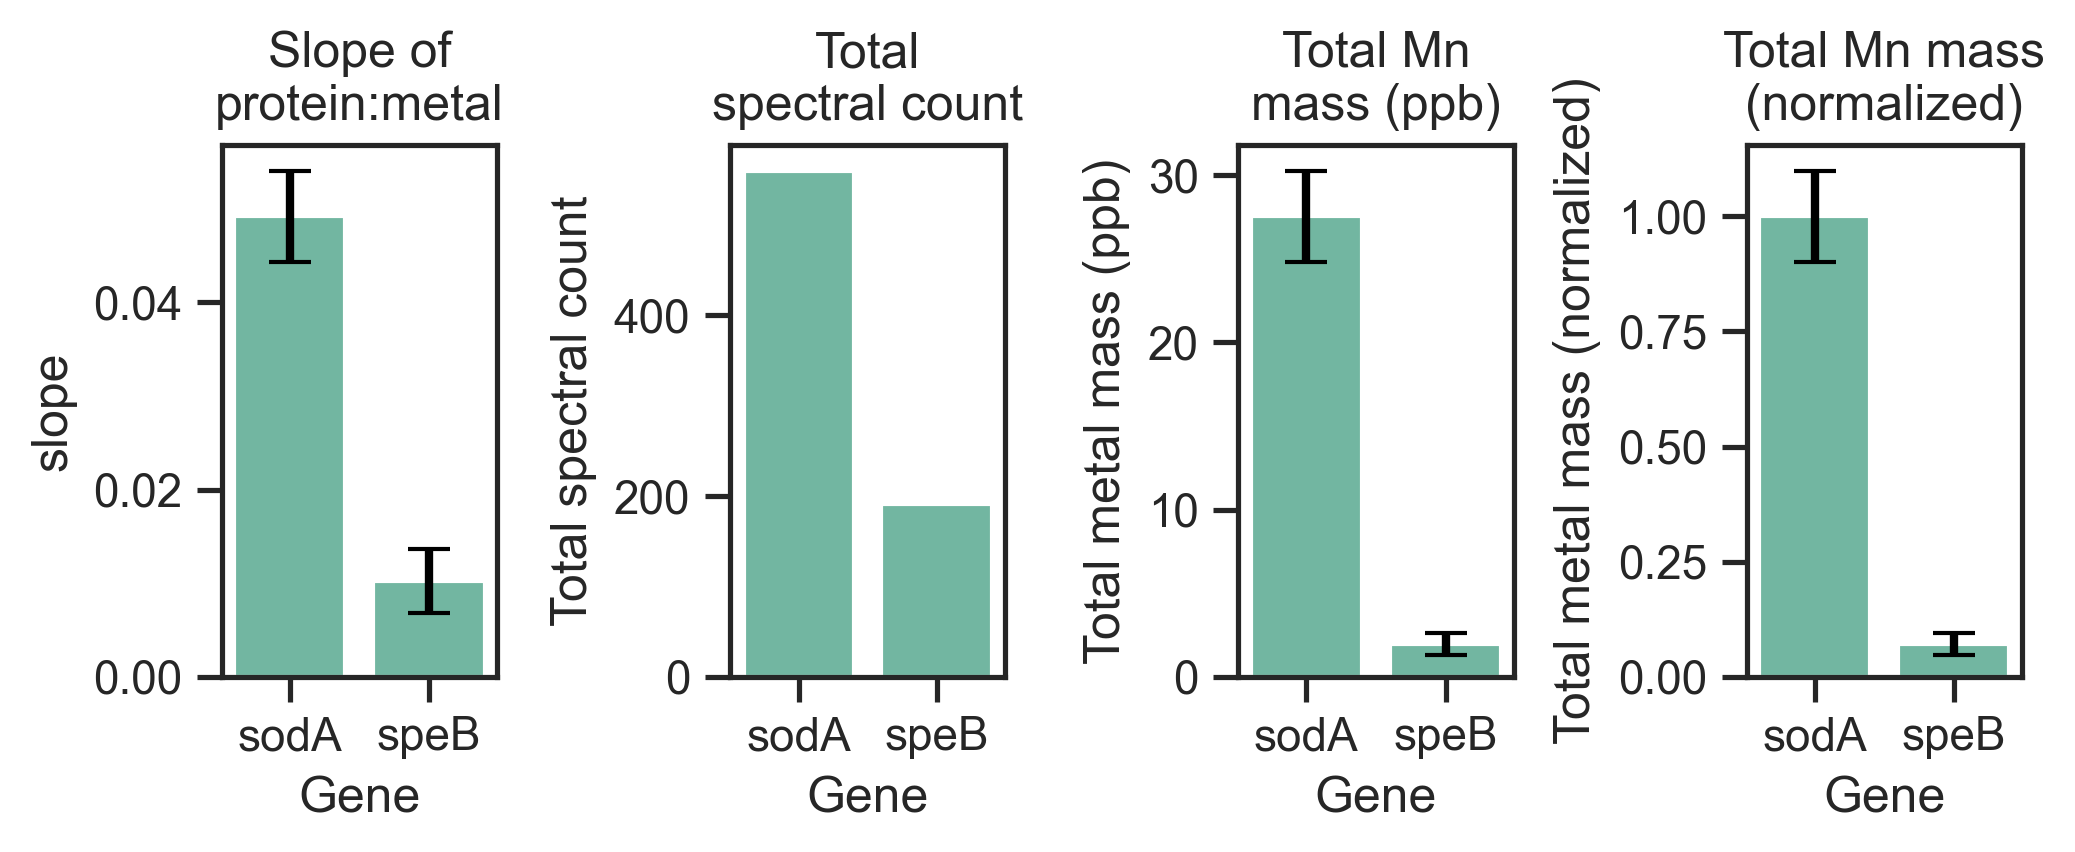

In [134]:
# create separate bar plots for slope, total spectral count, total metal mass and relative fraction
f, ax = plt.subplots(1, 4, figsize=(7, 3))

sns.barplot(x="Gene", y="slope", data=mn_reg.to_pandas(), ax=ax[0])
ax[0].set_title("Slope of\nprotein:metal")
# add error bar
ax[0].errorbar(x=mn_reg["Gene"].to_numpy(), y=mn_reg["slope"].to_numpy(), yerr=mn_reg["slope_std_err"].to_numpy(), fmt='none', ecolor='k', alpha=1, capsize=5, capthick=1, elinewidth=2)
sns.barplot(x="Gene", y="Total spectral count", data=mn_reg.to_pandas(), ax=ax[1])
ax[1].set_title("Total\nspectral count")
sns.barplot(x="Gene", y="Total metal mass (ppb)", data=mn_reg.to_pandas(), ax=ax[2])
ax[2].set_title("Total Mn\nmass (ppb)")
# add error bars based on Relative fraction std error
ax[2].errorbar(x=mn_reg["Gene"].to_numpy(), y=mn_reg["Total metal mass (ppb)"].to_numpy(), yerr=mn_reg["Relative fraction std error"].to_numpy(), fmt='none', ecolor='k', alpha=1, capsize=5, capthick=1, elinewidth=2)

# plot normalized metal mass
sns.barplot(x="Gene", y="Total metal mass (normalized)", data=mn_reg.to_pandas(), ax=ax[3])
ax[3].set_title("Total Mn mass\n(normalized)")
ax[3].errorbar(x=mn_reg["Gene"].to_numpy(), y=mn_reg["Total metal mass (normalized)"].to_numpy(), yerr=mn_reg["Relative fraction std error (normalized)"].to_numpy(), fmt='none', ecolor='k', alpha=1, capsize=5, capthick=1, elinewidth=2)

f.tight_layout()

# save as svg
f.savefig("figures/mn_regression_bars.svg", transparent=True)

# Check sulphur against Ni

<Axes: xlabel='34S', ylabel='59Co'>

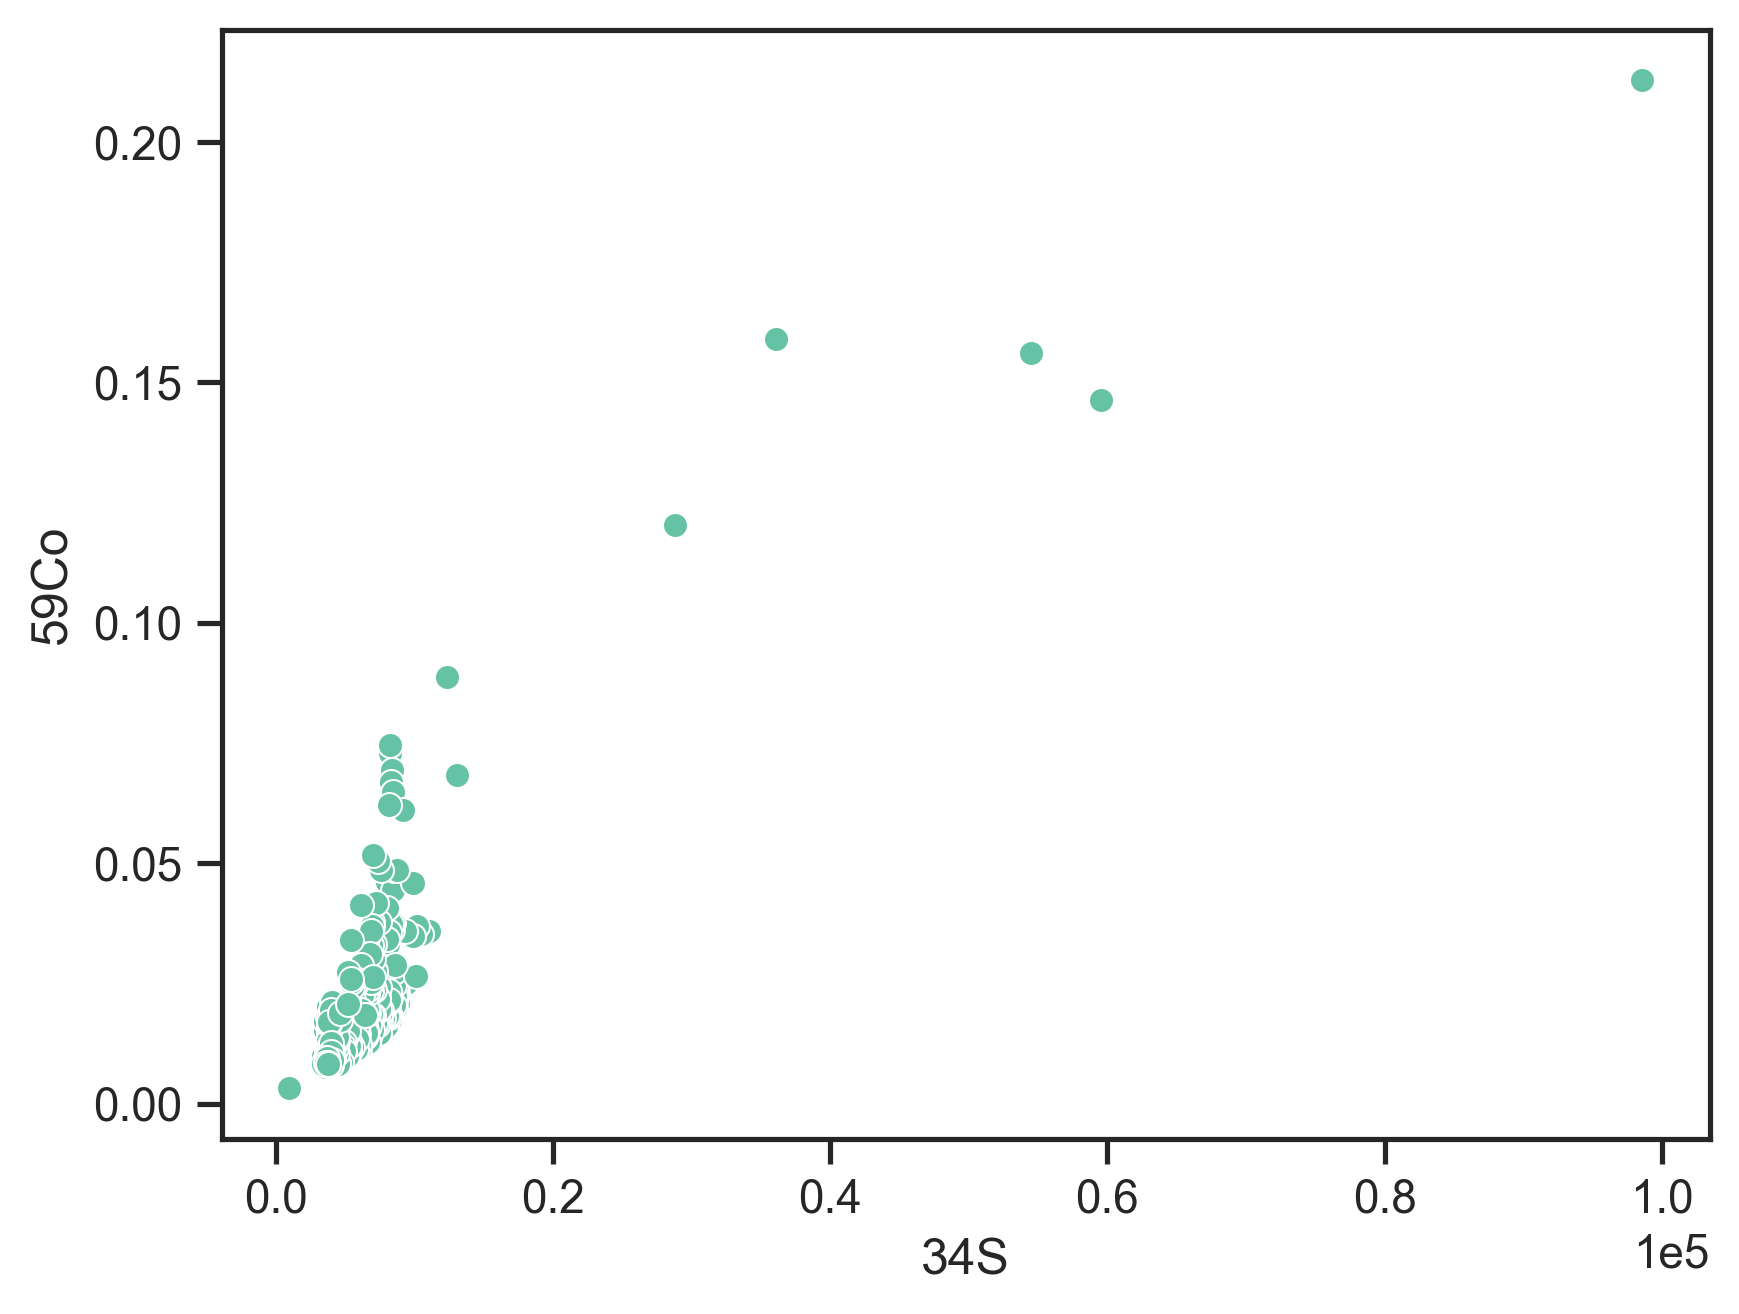

In [151]:
sns.scatterplot(x=metal_join_df["34S"], y=metal_join_df["59Co"])

#plt.xlim(0,10000)